In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

PROCESSED_DIR = Path('../../data/processed/Sephora')
OUTPUT_DIR = Path('outputs/sephora_segmentation')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

K_RANGE = range(2, 11)

In [5]:
df = pd.read_csv(PROCESSED_DIR / 'sephora_segmentation.csv')
print(f'{len(df):,} products loaded')
df.head()

1,632 products loaded


,product_id,bv_product_id,product_url,brand,product_name,category,price,rating,review_count,avg_rating,...,pct_skin_type_combination,pct_skin_type_combosk,pct_skin_type_dry,pct_skin_type_drysk,pct_skin_type_normalsk,pct_skin_type_oilysk,pct_skin_type_sensitivesk,pct_has_skin_type,price_bucket,price_vs_category_median
0,519902,519902,https://www.sephora.com/product/P519902,Rare Beauty by Selena Gomez,Warm Wishes Soft Matte Powder Bronzer - Rare B...,Bronzer,30.0,4.861330,278,4.780576,...,0.0,0.532374,0.0,0.212230,0.161871,0.093525,0.0,1.0,30-40,0.882353
1,520733,520733,https://www.sephora.com/product/cheirosa-91-ro...,Sol de Janeiro,Mini Cheirosa 91 Rosa Charmosa Body & Hair Per...,Body Mist & Hair Mist,26.0,4.226562,20,4.550000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,20-30,0.928571
2,406080,406080,https://www.sephora.com/product/brazilian-bum-...,Sol de Janeiro,Brazilian Bum Bum Body Cream - Sol de Janeiro,Body Lotions & Body Oils,48.0,4.283967,150,4.186667,...,0.0,0.480000,0.0,0.220000,0.206667,0.093333,0.0,1.0,40-50,1.297297
3,417312,417312,https://www.sephora.com/product/brazilian-crus...,Sol de Janeiro,Brazilian Crush Cheirosa ’62 Bum Bum Hair & Bo...,Body Mist & Hair Mist,39.0,4.429324,202,4.589109,...,0.0,0.500000,0.0,0.173267,0.207921,0.118812,0.0,1.0,30-40,1.392857
4,472072,472072,https://www.sephora.com/product/sol-de-janeiro...,Sol de Janeiro,Brazilian Crush Cheirosa ’40 Bom Dia Hair & Bo...,Body Mist & Hair Mist,26.0,4.550265,174,4.603448,...,0.0,0.419540,0.0,0.178161,0.258621,0.143678,0.0,1.0,20-30,0.928571


In [6]:
core_features = [
    'avg_rating', 'rating_std',
    'pct_5_star', 'pct_4_star', 'pct_3_star', 'pct_2_star', 'pct_1_star',
    'avg_sentiment', 'pct_positive', 'pct_negative',
    'reviews_per_month', 'review_count_normalized',
    'rating_dispersion_over_time', 'top_topic_prevalence',
    'dominant_topic_mode', 'price', 'price_vs_category_median',
    'avg_helpfulness',
]

skin_tone_cols = [c for c in df.columns if c.startswith('pct_skin_tone_')]
skin_type_cols = [c for c in df.columns if c.startswith('pct_skin_type_')]
coverage_cols = [c for c in df.columns if c in ('pct_has_skin_tone', 'pct_has_skin_type')]

feature_names = [f for f in core_features + skin_tone_cols + skin_type_cols + coverage_cols if f in df.columns]
print(f'Selected {len(feature_names)} features')

X = df[feature_names].apply(pd.to_numeric, errors='coerce').fillna(0)
weights = np.clip(pd.to_numeric(df['review_count_normalized'], errors='coerce').fillna(0).values, 0.1, 1.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Feature matrix: {X_scaled.shape}')

Selected 38 features
Feature matrix: (1632, 38)


In [7]:
def plot_silhouette_detail(X_scaled, labels, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    sil_vals = silhouette_samples(X_scaled, labels)
    n_clusters = len(set(labels))
    y_lower = 10

    for i in range(n_clusters):
        cluster_sil = np.sort(sil_vals[labels == i])
        size = len(cluster_sil)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 10

    avg_sil = sil_vals.mean()
    ax.axvline(avg_sil, color='red', linestyle='--', label=f'Avg: {avg_sil:.3f}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


profile_features = [
    'avg_rating', 'avg_sentiment', 'price', 'reviews_per_month',
    'pct_5_star', 'pct_1_star', 'pct_positive', 'pct_negative',
    'rating_std', 'price_vs_category_median', 'review_count_normalized',
    'top_topic_prevalence', 'rating_dispersion_over_time',
]
profile_features = [f for f in profile_features if f in df.columns]


def profile_clusters(df, col):
    profiles = df.groupby(col)[profile_features].mean()
    profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(14, max(6, len(profiles) * 1.5)))
    sns.heatmap(profiles_norm.T, annot=profiles.T.round(3), fmt='', cmap='YlOrRd',
                xticklabels=[f'Cluster {i}' for i in profiles.index],
                yticklabels=profiles.columns, ax=ax, linewidths=0.5)
    ax.set_title(f'Cluster Profiles — {col}', fontsize=14)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'profile_{col}.png', dpi=150)
    plt.show()

    for cluster_id in sorted(df[col].unique()):
        c = df[df[col] == cluster_id]
        print(f'\n  Cluster {cluster_id} ({len(c):,} products, {len(c)/len(df)*100:.1f}%)')
        print(f'  Top categories: {c["category"].value_counts().head(5).to_dict()}')
        print(f'  Top brands: {c["brand"].value_counts().head(5).to_dict()}')
        print(f'  Price: ${c["price"].min():.0f}-${c["price"].max():.0f} (median ${c["price"].median():.0f})')
        print(f'  Avg rating: {c["avg_rating"].mean():.2f}  |  Avg sentiment: {c["avg_sentiment"].mean():.3f}')
        print(f'  Reviews/month: {c["reviews_per_month"].mean():.1f}  |  Rating std: {c["rating_std"].mean():.3f}')

# Model 1: K-Means Unweighted

  k=2: WCSS=51,358  silhouette=0.3408
  k=3: WCSS=45,211  silhouette=0.1934
  k=4: WCSS=43,317  silhouette=0.1221
  k=5: WCSS=41,517  silhouette=0.1221
  k=6: WCSS=39,867  silhouette=0.1335
  k=7: WCSS=38,240  silhouette=0.1345
  k=8: WCSS=37,602  silhouette=0.1350
  k=9: WCSS=36,187  silhouette=0.1152
  k=10: WCSS=34,898  silhouette=0.1239


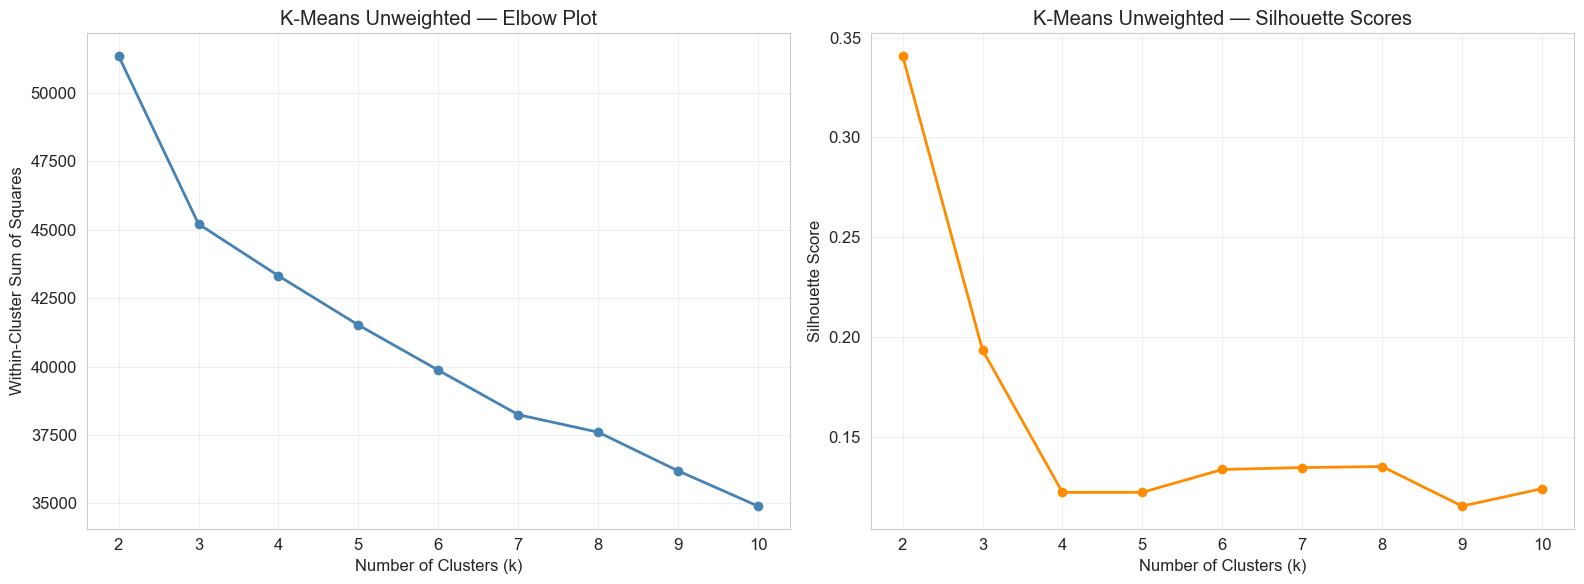

In [8]:
km_uw_inertias, km_uw_silhouettes, km_uw_models = [], [], {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    km_uw_inertias.append(km.inertia_)
    km_uw_silhouettes.append(sil)
    km_uw_models[k] = km
    print(f'  k={k}: WCSS={km.inertia_:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(list(K_RANGE), km_uw_inertias, 'o-', linewidth=2, color='steelblue')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares')
ax1.set_title('K-Means Unweighted — Elbow Plot')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), km_uw_silhouettes, 'o-', linewidth=2, color='darkorange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('K-Means Unweighted — Silhouette Scores')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'km_uw_elbow_silhouette.png', dpi=150)
plt.show()

In [9]:
KM_UW_K = 3

K-Means Unweighted (k=3): silhouette=0.1934


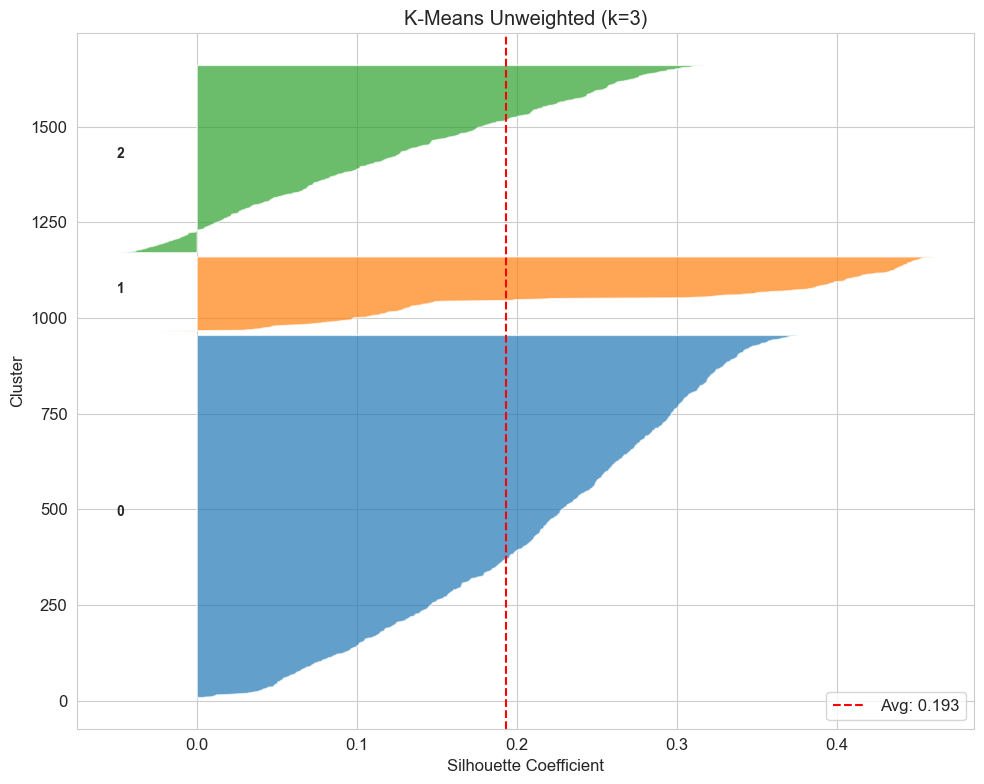

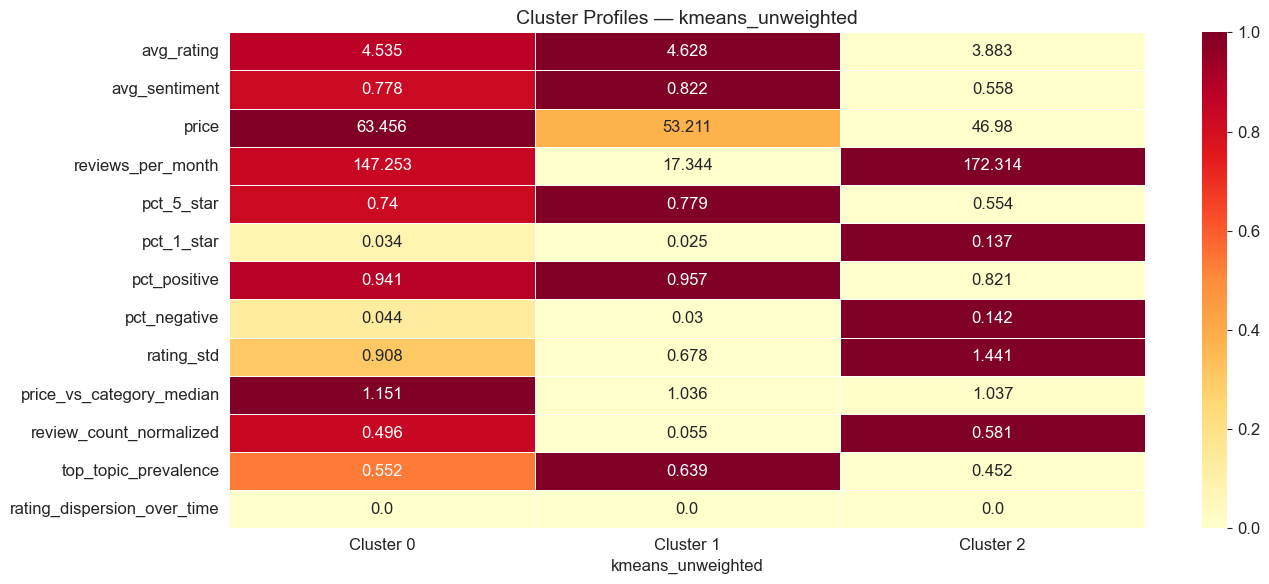


  Cluster 0 (947 products, 58.0%)
  Top categories: {'Perfume': 82, 'Face Serums': 59, 'Face Creams': 57, 'Shampoo': 44, 'Cologne': 36}
  Top brands: {'Versace': 8, 'La Mer': 7, 'OUAI': 7, 'Rabanne': 7, 'Virtue': 7}
  Price: $0-$749 (median $39)
  Avg rating: 4.53  |  Avg sentiment: 0.778
  Reviews/month: 147.3  |  Rating std: 0.908

  Cluster 1 (195 products, 11.9%)
  Top categories: {'Perfume': 26, 'Value & Gift Sets': 21, 'Perfume Gift Sets': 21, 'Rollerballs & Travel Size': 14, 'Lip Balms & Treatments': 12}
  Top brands: {'Kenra Professional': 5, 'Miu Miu': 5, 'Dr. Jart+': 5, 'Ebb Ocean Club': 5, 'Erborian': 5}
  Price: $7-$190 (median $35)
  Avg rating: 4.63  |  Avg sentiment: 0.822
  Reviews/month: 17.3  |  Rating std: 0.678

  Cluster 2 (490 products, 30.0%)
  Top categories: {'Perfume': 23, 'Face Serums': 21, 'Foundation': 20, 'Value & Gift Sets': 20, 'Face Wash & Cleansers': 15}
  Top brands: {'OLEHENRIKSEN': 7, 'Drybar': 7, 'HAUS LABS BY LADY GAGA': 7, 'MERIT': 6, 'Benefit C

In [10]:
df['kmeans_unweighted'] = km_uw_models[KM_UW_K].labels_
sil = silhouette_score(X_scaled, df['kmeans_unweighted'].values)
print(f'K-Means Unweighted (k={KM_UW_K}): silhouette={sil:.4f}')

plot_silhouette_detail(X_scaled, df['kmeans_unweighted'].values,
                       f'K-Means Unweighted (k={KM_UW_K})')

profile_clusters(df, 'kmeans_unweighted')

K-Means Unweighted (k=3): silhouette=0.1934



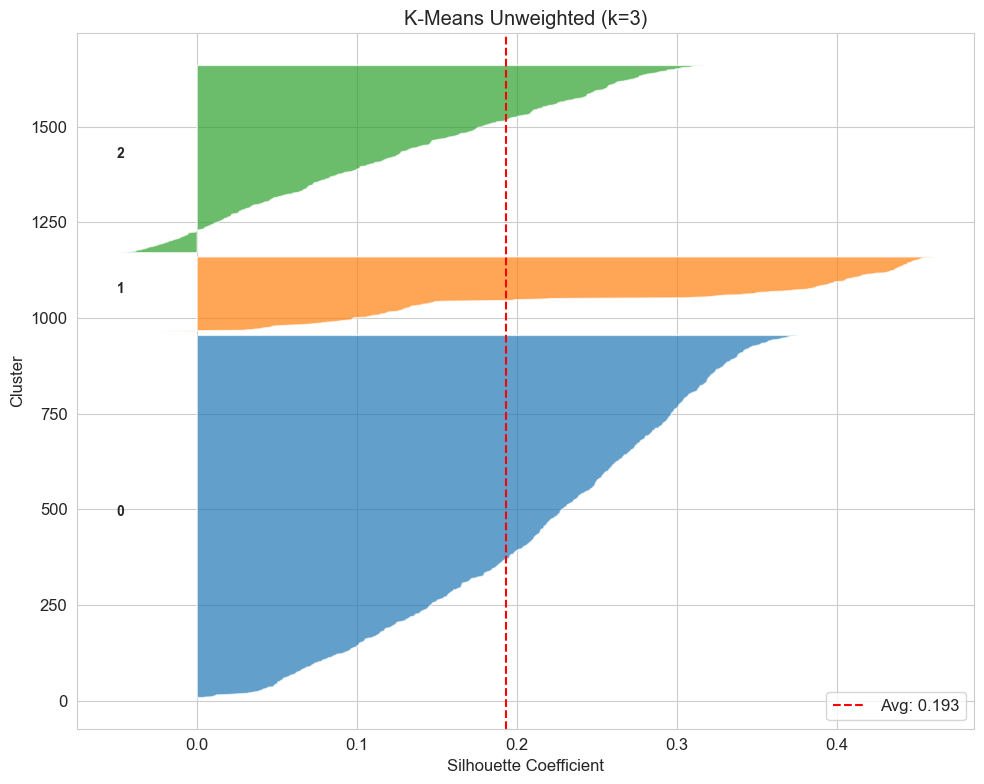


CLUSTER 0 — 947 products (58.0%)

  --- Product Info ---
  Top categories:  {'Perfume': 82, 'Face Serums': 59, 'Face Creams': 57, 'Shampoo': 44, 'Cologne': 36}
  Top brands:      {'Versace': 8, 'La Mer': 7, 'OUAI': 7, 'Rabanne': 7, 'Virtue': 7}
  Price range:     $0.01 - $749.00
  Price median:    $39.00
  Price mean:      $63.46
  Price vs cat median: 1.151
  Price bucket dist:
    30-40: 237 (25.0%)
    20-30: 183 (19.3%)
    40-50: 122 (12.9%)
    50-60: 64 (6.8%)
    10-20: 60 (6.3%)

  --- Ratings ---
  Avg rating:      4.535
  Rating std:      0.908
  Rating dispersion over time: 0.000
  Pct 5-star:      0.740 (74.0%)
  Pct 4-star:      0.150 (15.0%)
  Pct 3-star:      0.048 (4.8%)
  Pct 2-star:      0.028 (2.8%)
  Pct 1-star:      0.034 (3.4%)

  --- Sentiment ---
  Avg sentiment:   0.778
  Pct positive:    0.941 (94.1%)
  Pct negative:    0.044 (4.4%)
  Pct neutral:     0.015 (1.5%)

  --- Review Velocity & Engagement ---
  Review count (mean):       147.3
  Review count (medi

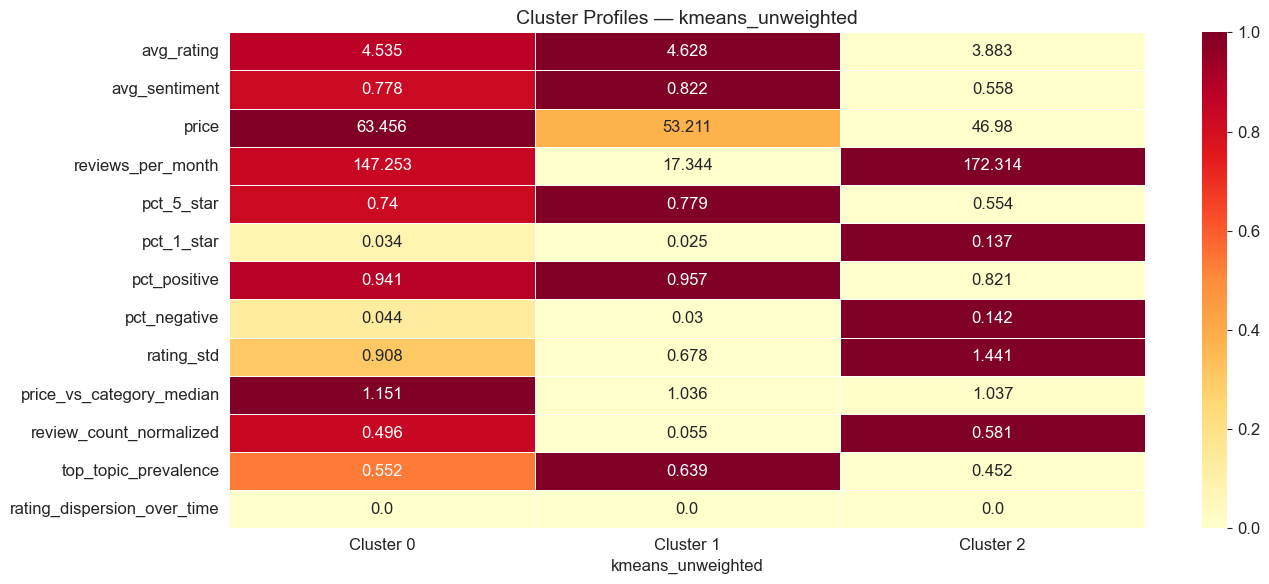


  Cluster 0 (947 products, 58.0%)
  Top categories: {'Perfume': 82, 'Face Serums': 59, 'Face Creams': 57, 'Shampoo': 44, 'Cologne': 36}
  Top brands: {'Versace': 8, 'La Mer': 7, 'OUAI': 7, 'Rabanne': 7, 'Virtue': 7}
  Price: $0-$749 (median $39)
  Avg rating: 4.53  |  Avg sentiment: 0.778
  Reviews/month: 147.3  |  Rating std: 0.908

  Cluster 1 (195 products, 11.9%)
  Top categories: {'Perfume': 26, 'Value & Gift Sets': 21, 'Perfume Gift Sets': 21, 'Rollerballs & Travel Size': 14, 'Lip Balms & Treatments': 12}
  Top brands: {'Kenra Professional': 5, 'Miu Miu': 5, 'Dr. Jart+': 5, 'Ebb Ocean Club': 5, 'Erborian': 5}
  Price: $7-$190 (median $35)
  Avg rating: 4.63  |  Avg sentiment: 0.822
  Reviews/month: 17.3  |  Rating std: 0.678

  Cluster 2 (490 products, 30.0%)
  Top categories: {'Perfume': 23, 'Face Serums': 21, 'Foundation': 20, 'Value & Gift Sets': 20, 'Face Wash & Cleansers': 15}
  Top brands: {'OLEHENRIKSEN': 7, 'Drybar': 7, 'HAUS LABS BY LADY GAGA': 7, 'MERIT': 6, 'Benefit C

In [11]:
KM_UW_K = 3
df['kmeans_unweighted'] = km_uw_models[KM_UW_K].labels_

sil = silhouette_score(X_scaled, df['kmeans_unweighted'].values)
print(f'K-Means Unweighted (k={KM_UW_K}): silhouette={sil:.4f}\n')

plot_silhouette_detail(X_scaled, df['kmeans_unweighted'].values,
                       f'K-Means Unweighted (k={KM_UW_K})')

# Full breakdown of every feature per cluster
for cluster_id in sorted(df['kmeans_unweighted'].unique()):
    c = df[df['kmeans_unweighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Avg helpfulness:           {c["avg_helpfulness"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    # Skin tone columns (dynamic)
    skin_tone_cols = [col for col in c.columns if col.startswith('pct_skin_tone_')]
    if skin_tone_cols:
        print(f'\n  --- Skin Tone Distribution ---')
        if 'pct_has_skin_tone' in c.columns:
            print(f'  Pct with skin tone data: {c["pct_has_skin_tone"].mean():.3f} ({c["pct_has_skin_tone"].mean()*100:.1f}%)')
        for col in sorted(skin_tone_cols):
            label = col.replace('pct_skin_tone_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    # Skin type columns (dynamic)
    skin_type_cols = [col for col in c.columns if col.startswith('pct_skin_type_')]
    if skin_type_cols:
        print(f'\n  --- Skin Type Distribution ---')
        if 'pct_has_skin_type' in c.columns:
            print(f'  Pct with skin type data: {c["pct_has_skin_type"].mean():.3f} ({c["pct_has_skin_type"].mean()*100:.1f}%)')
        for col in sorted(skin_type_cols):
            label = col.replace('pct_skin_type_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

# Heatmap
profile_clusters(df, 'kmeans_unweighted')

In [12]:
for cluster_id in sorted(df['kmeans_unweighted'].unique()):
    c = df[df['kmeans_unweighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')


CLUSTER 0 — 947 products, 8 unique brands
  Versace                                         8 (0.8%)
  La Mer                                          7 (0.7%)
  OUAI                                            7 (0.7%)
  Rabanne                                         7 (0.7%)
  Virtue                                          7 (0.7%)
  PATTERN by Tracee Ellis Ross                    6 (0.6%)
  Mizani                                          6 (0.6%)
  Montblanc                                       6 (0.6%)
  Nécessaire                                      6 (0.6%)
  Oribe                                           6 (0.6%)
  Ralph Lauren                                    6 (0.6%)
  BURBERRY                                        6 (0.6%)
  Fable & Mane                                    6 (0.6%)
  Sol de Janeiro                                  5 (0.5%)
  m.ph by Mary Phillips                           5 (0.5%)
  Glossier                                        5 (0.5%)
  Harlem Perf

Here's how these segments break down:

## Cluster 0 — "Premium Steady Performers" (947 products, 58%)

The bulk of Sephora's catalog. These are well-reviewed, well-liked products at slightly above-category-median pricing ($63 avg, highest of the three). Strong ratings (4.53) and high positive sentiment (94.1%) with low complaint rates. Moderate review velocity — they get attention but aren't viral. Dominated by skincare (serums, creams) and fragrance, with prestige brands like La Mer and Versace. Nearly all reviewers provide skin tone/type data (97-98%), meaning these attract engaged, profile-completing shoppers. The "reliable workhorse" tier — not controversial, not explosive, just consistently good.

## Cluster 1 — "Niche Darlings" (195 products, 12%)

The smallest cluster but the highest rated (4.63) and most positive sentiment (0.822). The catch: barely anyone is reviewing them — 17 reviews/month vs 147-172 for the other clusters. These are low-visibility products that the few people who find them absolutely love. Heavy on gift sets, rollerballs, and travel sizes — discovery formats. Almost zero skin tone data (0%), which means these are categories where skin matching doesn't apply (fragrance, sets, lip). Topic 3 (received product/honest review) is overrepresented at 23.6%, suggesting a lot of PR/gifted product reviews. High top topic prevalence (63.9%) means reviews are thematically narrow — people are all saying the same thing.

## Cluster 2 — "Polarizing High-Traffic" (490 products, 30%)

The most reviewed products (172/month) but the lowest rated (3.88) with the highest rating variance (1.44 std). These products generate strong opinions in both directions — 55% five-star but also 13.7% one-star, which is 4x Cluster 0's rate. Negative sentiment at 14.2% is triple Cluster 0. Highest helpfulness score (5.0) meaning people are actively voting on reviews — a sign of purchase-decision anxiety where shoppers are digging through reviews before buying. Foundation shows up here (shade matching is polarizing), along with cleansers and makeup brands like Haus Labs and Benefit. These are the products people talk about a lot but disagree on — the ones driving the most contentious review threads.

## The strategic read: 
Cluster 0 is your safe catalog backbone. Cluster 1 is undiscovered — potential for growth if promoted, but could also just be low-demand. Cluster 2 is where marketing needs to intervene — high engagement but high dissatisfaction means reformulation, better shade ranges, or expectation-setting through content could shift sentiment.

# Model 2: K-means (Weighted)

In [13]:
# Feature importance weights
feature_weights = {}
for f in feature_names:
    if f in ('reviews_per_month', 'review_count_normalized'):
        feature_weights[f] = 2.0  # review velocity
    elif f in ('avg_sentiment', 'pct_positive', 'pct_negative', 'pct_neutral'):
        feature_weights[f] = 2.0  # sentiment ratios
    elif f in ('rating_std', 'rating_dispersion_over_time'):
        feature_weights[f] = 2.0  # rating variance/stability
    elif f.startswith('pct_skin_tone_') or f.startswith('pct_skin_type_') or f in ('pct_has_skin_tone', 'pct_has_skin_type'):
        feature_weights[f] = 1.5  # retailer-specific
    elif f in ('avg_helpfulness',):
        feature_weights[f] = 1.5  # retailer-specific
    else:
        feature_weights[f] = 1.0  # default

# Apply weights to scaled features
weight_array = np.array([feature_weights[f] for f in feature_names])
X_weighted = X_scaled * weight_array

print('Feature weights:')
for f, w in sorted(feature_weights.items(), key=lambda x: -x[1]):
    print(f'  {f:<40} {w:.1f}')

Feature weights:
  rating_std                               2.0
  avg_sentiment                            2.0
  pct_positive                             2.0
  pct_negative                             2.0
  reviews_per_month                        2.0
  review_count_normalized                  2.0
  rating_dispersion_over_time              2.0
  avg_helpfulness                          1.5
  pct_skin_tone_deep                       1.5
  pct_skin_tone_fair                       1.5
  pct_skin_tone_fairlight                  1.5
  pct_skin_tone_light                      1.5
  pct_skin_tone_lightmedium                1.5
  pct_skin_tone_medium                     1.5
  pct_skin_tone_mediumtan                  1.5
  pct_skin_tone_notsurest                  1.5
  pct_skin_tone_olive                      1.5
  pct_skin_tone_rich                       1.5
  pct_skin_tone_tan                        1.5
  pct_skin_type_combination                1.5
  pct_skin_type_combosk                    

  k=2: WCSS=110,434  silhouette=0.3620
  k=3: WCSS=94,958  silhouette=0.2176
  k=4: WCSS=89,402  silhouette=0.1396
  k=5: WCSS=85,693  silhouette=0.1501
  k=6: WCSS=81,887  silhouette=0.1466
  k=7: WCSS=78,528  silhouette=0.1330
  k=8: WCSS=74,855  silhouette=0.1334
  k=9: WCSS=72,493  silhouette=0.1678
  k=10: WCSS=69,945  silhouette=0.1330


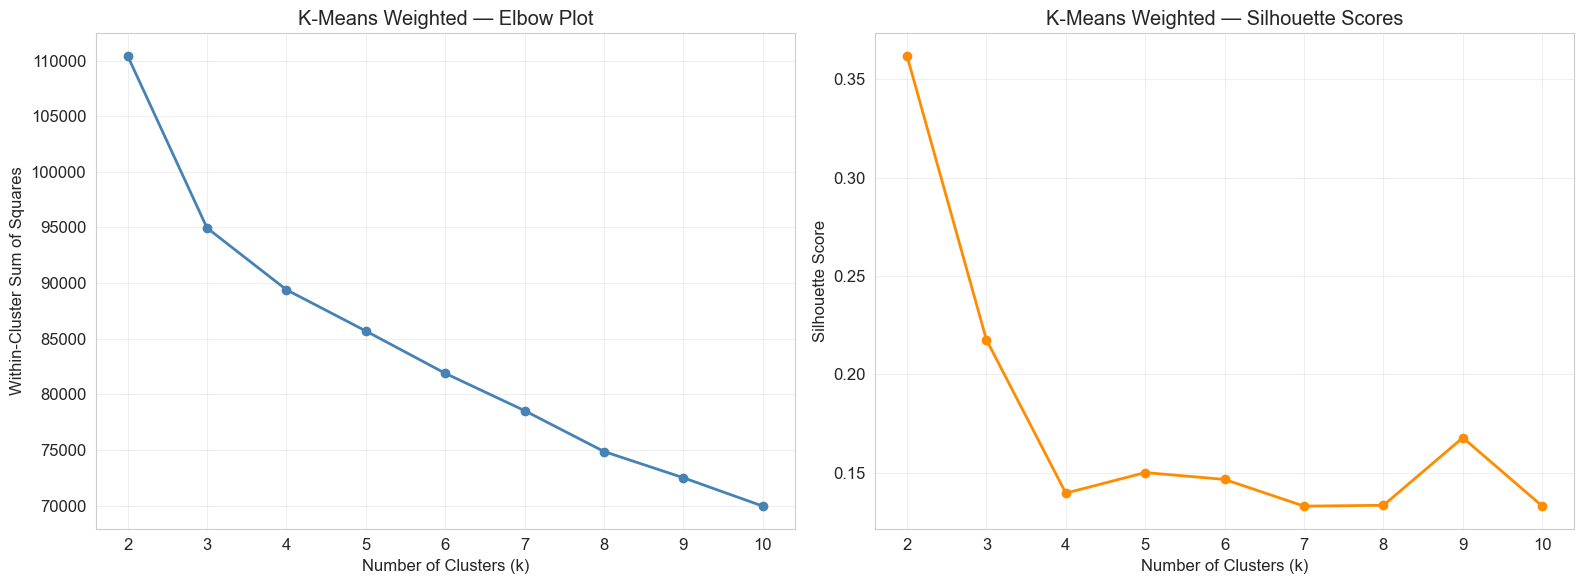

In [14]:
km_w_inertias, km_w_silhouettes, km_w_models = [], [], {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_weighted)
    sil = silhouette_score(X_weighted, km.labels_)
    km_w_inertias.append(km.inertia_)
    km_w_silhouettes.append(sil)
    km_w_models[k] = km
    print(f'  k={k}: WCSS={km.inertia_:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(list(K_RANGE), km_w_inertias, 'o-', linewidth=2, color='steelblue')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares')
ax1.set_title('K-Means Weighted — Elbow Plot')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), km_w_silhouettes, 'o-', linewidth=2, color='darkorange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('K-Means Weighted — Silhouette Scores')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'km_w_elbow_silhouette.png', dpi=150)
plt.show()

In [15]:
KM_W_K = 4

K-Means Weighted (k=4): silhouette=0.1396



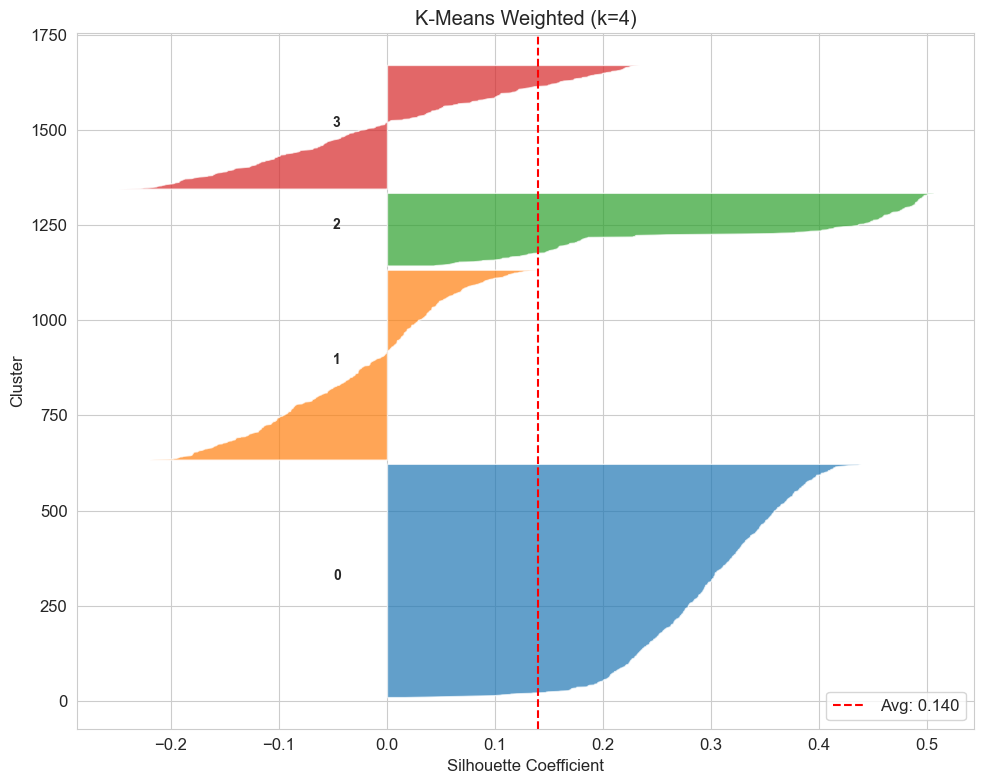


CLUSTER 0 — 614 products (37.6%)

  --- Product Info ---
  Top categories:  {'Perfume': 67, 'Face Serums': 31, 'Face Creams': 29, 'Blush': 28, 'Shampoo': 28}
  Top brands:      {'Sol de Janeiro': 8, 'PAT McGRATH LABS': 7, 'Virtue': 7, 'Westman Atelier': 7, 'MERIT': 6}
  Price range:     $0.01 - $495.00
  Price median:    $38.50
  Price mean:      $59.58
  Price vs cat median: 1.155
  Price bucket dist:
    30-40: 168 (27.4%)
    20-30: 129 (21.0%)
    40-50: 76 (12.4%)
    50-60: 43 (7.0%)
    60-70: 34 (5.5%)

  --- Ratings ---
  Avg rating:      4.366
  Rating std:      1.086
  Rating dispersion over time: 0.000
  Pct 5-star:      0.677 (67.7%)
  Pct 4-star:      0.162 (16.2%)
  Pct 3-star:      0.066 (6.6%)
  Pct 2-star:      0.042 (4.2%)
  Pct 1-star:      0.054 (5.4%)

  --- Sentiment ---
  Avg sentiment:   0.728
  Pct positive:    0.917 (91.7%)
  Pct negative:    0.064 (6.4%)
  Pct neutral:     0.019 (1.9%)

  --- Review Velocity & Engagement ---
  Review count (mean):       213

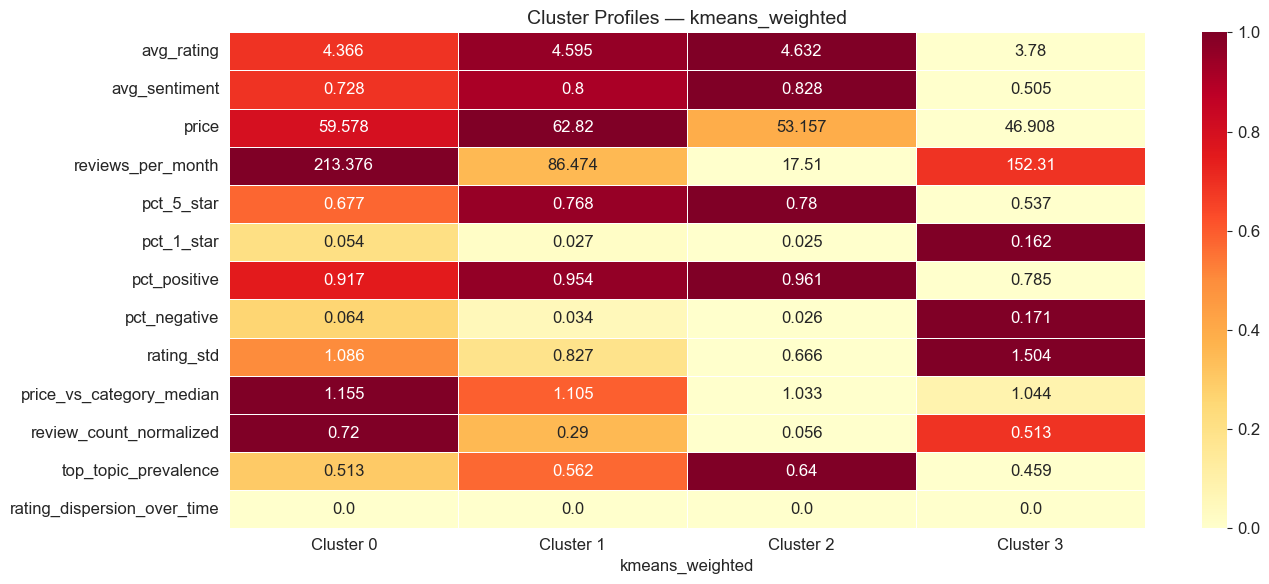


  Cluster 0 (614 products, 37.6%)
  Top categories: {'Perfume': 67, 'Face Serums': 31, 'Face Creams': 29, 'Blush': 28, 'Shampoo': 28}
  Top brands: {'Sol de Janeiro': 8, 'PAT McGRATH LABS': 7, 'Virtue': 7, 'Westman Atelier': 7, 'MERIT': 6}
  Price: $0-$495 (median $38)
  Avg rating: 4.37  |  Avg sentiment: 0.728
  Reviews/month: 213.4  |  Rating std: 1.086

  Cluster 1 (500 products, 30.6%)
  Top categories: {'Face Serums': 35, 'Face Creams': 32, 'Perfume': 31, 'Value & Gift Sets': 29, 'Cologne': 29}
  Top brands: {'PATTERN by Tracee Ellis Ross': 5, 'Harlem Perfume Co.': 5, 'Beauty of Joseon': 5, 'Jo Malone London': 5, 'Katini Skin': 5}
  Price: $5-$749 (median $38)
  Avg rating: 4.59  |  Avg sentiment: 0.800
  Reviews/month: 86.5  |  Rating std: 0.827

  Cluster 2 (192 products, 11.8%)
  Top categories: {'Perfume': 26, 'Value & Gift Sets': 21, 'Perfume Gift Sets': 21, 'Rollerballs & Travel Size': 12, 'Lip Balms & Treatments': 12}
  Top brands: {'Kenra Professional': 5, 'Miu Miu': 5, 

In [16]:
df['kmeans_weighted'] = km_w_models[KM_W_K].labels_
sil = silhouette_score(X_weighted, df['kmeans_weighted'].values)
print(f'K-Means Weighted (k={KM_W_K}): silhouette={sil:.4f}\n')

plot_silhouette_detail(X_weighted, df['kmeans_weighted'].values,
                       f'K-Means Weighted (k={KM_W_K})')

for cluster_id in sorted(df['kmeans_weighted'].unique()):
    c = df[df['kmeans_weighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Avg helpfulness:           {c["avg_helpfulness"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    skin_tone_cols = [col for col in c.columns if col.startswith('pct_skin_tone_')]
    if skin_tone_cols:
        print(f'\n  --- Skin Tone Distribution ---')
        if 'pct_has_skin_tone' in c.columns:
            print(f'  Pct with skin tone data: {c["pct_has_skin_tone"].mean():.3f} ({c["pct_has_skin_tone"].mean()*100:.1f}%)')
        for col in sorted(skin_tone_cols):
            label = col.replace('pct_skin_tone_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    skin_type_cols = [col for col in c.columns if col.startswith('pct_skin_type_')]
    if skin_type_cols:
        print(f'\n  --- Skin Type Distribution ---')
        if 'pct_has_skin_type' in c.columns:
            print(f'  Pct with skin type data: {c["pct_has_skin_type"].mean():.3f} ({c["pct_has_skin_type"].mean()*100:.1f}%)')
        for col in sorted(skin_type_cols):
            label = col.replace('pct_skin_type_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

# Full brand lists
for cluster_id in sorted(df['kmeans_weighted'].unique()):
    c = df[df['kmeans_weighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

# Heatmap
profile_clusters(df, 'kmeans_weighted')

The weighting split the old Cluster 0 (the 58% "steady performers") into two more meaningful groups, and sharpened Cluster 3. Here's the read:

## Cluster 0 — "High-Traffic Mainstream" (614 products, 37.6%)

The most-reviewed products on Sephora (213 reviews/month). Good but not great ratings (4.37) with moderate variance (1.09 std). These are the products driving traffic — blush, serums, shampoo, fragrance — from recognizable prestige brands (Pat McGrath, Merit, Sol de Janeiro). 100% skin tone/type coverage means these are core beauty categories where shoppers self-identify. Sentiment is solid (91.7% positive) but the 6.4% negative rate is double Cluster 1's. These are the products people buy, review a lot, and mostly like — but there's enough dissatisfaction to generate debate. The engine of Sephora's review ecosystem.

## Cluster 1 — "Quiet Loyalists" (500 products, 30.6%)

The weighting pulled this out of the old massive Cluster 0. Moderate review velocity (86/month — half of Cluster 0), but higher ratings (4.59) and stronger sentiment (0.80). Lower rating variance (0.83) means people consistently agree these are good. More niche/indie brands (Pattern, Beauty of Joseon, Harlem Perfume Co., Katini Skin) plus prestige fragrance (Jo Malone). Strong skincare representation (serums + creams as top categories). These products don't generate viral review volume but maintain steady, loyal audiences. The weighting surfaced this as distinct from Cluster 0 because the sentiment and stability signals are meaningfully different despite similar pricing.

## Cluster 2 — "Low-Visibility Darlings" (192 products, 11.8%)

Nearly identical to the unweighted Cluster 1 — the weights didn't change this group because it was already defined by its extreme low velocity (17.5/month). Highest ratings (4.63), best sentiment (0.828), lowest variance (0.67). Fragrance-heavy (perfume + gift sets + rollerballs). Zero skin tone data because these are non-skin categories. Heavy Topic 3 presence (24% — "received product/honest review") suggests PR/gifted sampling. These are products barely anyone discovers, but the few who do love them. Growth opportunity if amplified.

## Cluster 3 — "Polarizing Problem Children" (326 products, 20.0%)

The sharpest cluster. Lowest ratings (3.78), worst sentiment (0.505), highest variance (1.50), highest negative sentiment (17.1%). Foundation is now a top category (shade-matching frustration), plus mini sizes and gift sets (which get "not worth the price" reviews). Brands like Kosas, Benefit, NARS — established names where expectations are high and disappointment is vocal. Highest helpfulness scores (5.3 from the unweighted run) confirm purchase-anxiety behavior. Topic 6 dominates (32.5%), which from your topic labels is the "tried/used/product" experiential language — people narrating their disappointment. These need intervention: reformulation, shade expansion, better product descriptions, or expectation management through content.

## What the weighting changed: 
It split the old 58% bulk cluster into "high-traffic mainstream" (Cluster 0) and "quiet loyalists" (Cluster 1) by amplifying the sentiment and velocity differences between them. It also sharpened Cluster 3 by pulling out the truly polarizing products more aggressively — note the rating std went from 1.44 (unweighted) to 1.50 (weighted), meaning the weights concentrated the most controversial products more tightly.

# Model 3: Hierarchal Clustering (Unweighted)

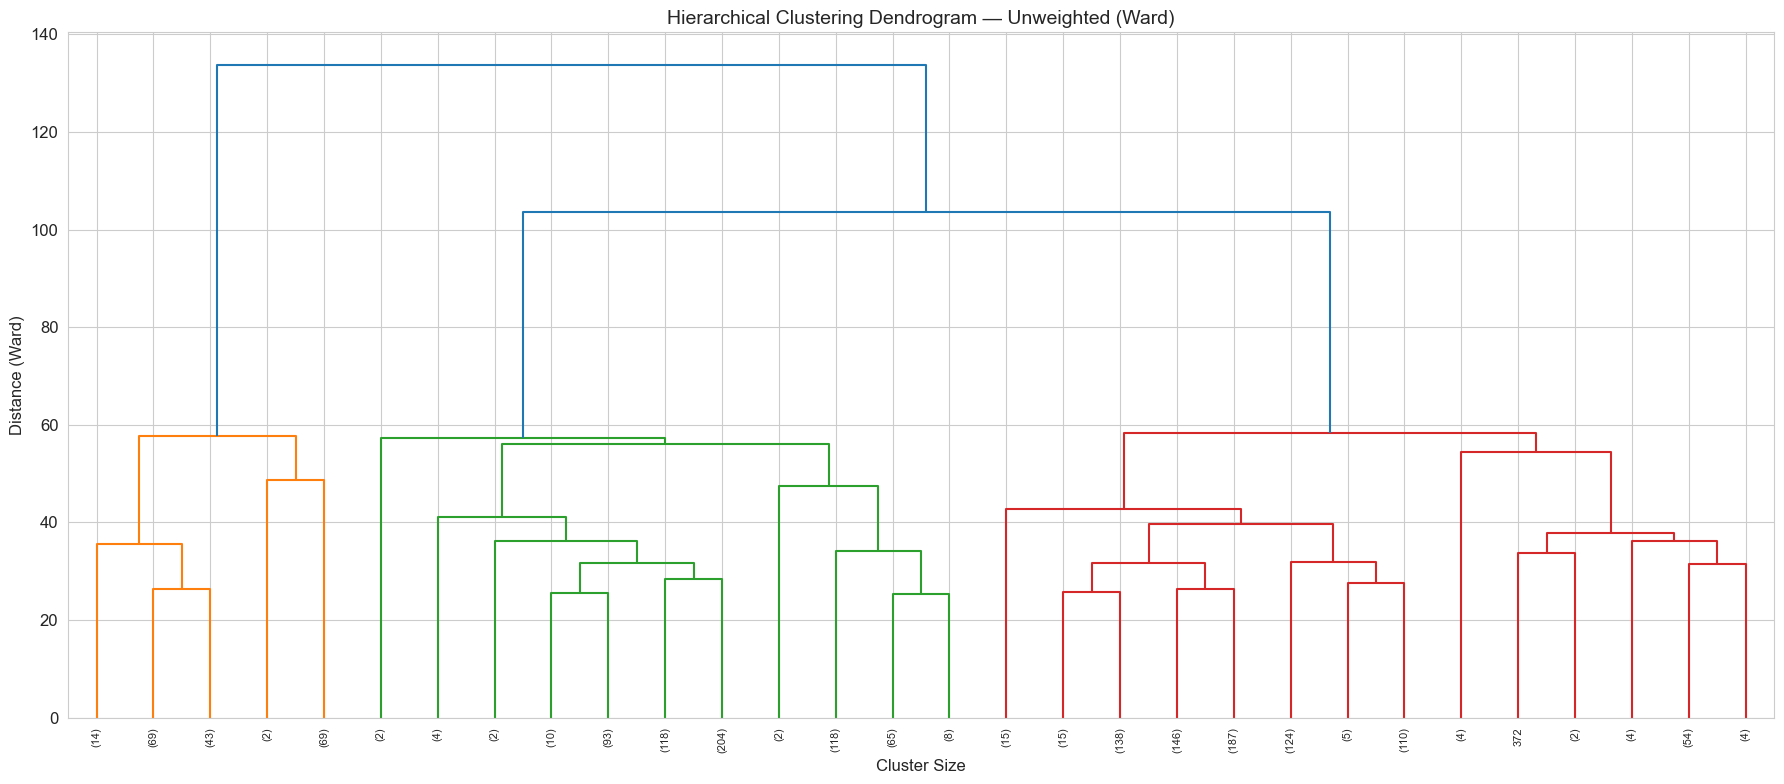

  k=2: silhouette=0.3333
  k=3: silhouette=0.1593
  k=4: silhouette=0.1542
  k=5: silhouette=0.1653
  k=6: silhouette=0.1667
  k=7: silhouette=0.1199
  k=8: silhouette=0.1238
  k=9: silhouette=0.1243
  k=10: silhouette=0.1258


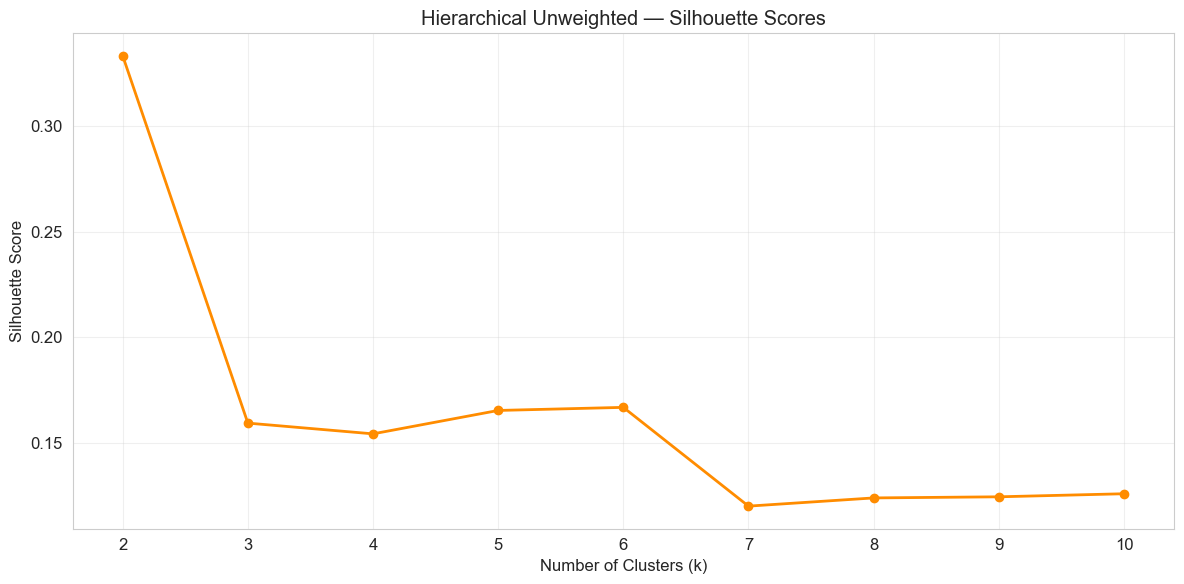

In [17]:
# Compute linkage matrix
Z_uw = linkage(X_scaled, method='ward')

# Dendrogram
fig, ax = plt.subplots(figsize=(18, 8))
dendrogram(Z_uw, truncate_mode='lastp', p=30,
           show_leaf_counts=True, ax=ax, leaf_rotation=90, leaf_font_size=8)
ax.set_title('Hierarchical Clustering Dendrogram — Unweighted (Ward)', fontsize=14)
ax.set_xlabel('Cluster Size')
ax.set_ylabel('Distance (Ward)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hc_uw_dendrogram.png', dpi=150)
plt.show()

# Silhouette across k
hc_uw_silhouettes, hc_uw_labels = [], {}

for k in K_RANGE:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    hc_uw_silhouettes.append(sil)
    hc_uw_labels[k] = labels
    print(f'  k={k}: silhouette={sil:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(list(K_RANGE), hc_uw_silhouettes, 'o-', linewidth=2, color='darkorange')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Hierarchical Unweighted — Silhouette Scores')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hc_uw_silhouette.png', dpi=150)
plt.show()

In [18]:
HC_UW_K = 3

Hierarchical Unweighted (k=3): silhouette=0.1593



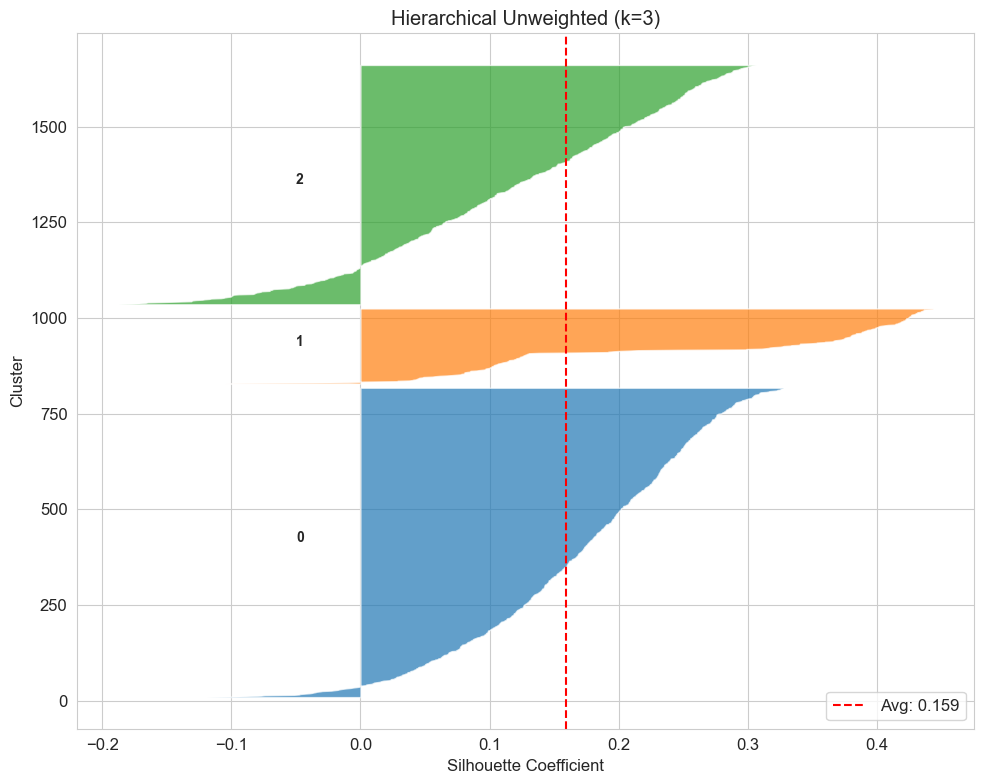


CLUSTER 0 — 809 products (49.6%)

  --- Product Info ---
  Top categories:  {'Perfume': 57, 'Face Creams': 53, 'Face Serums': 52, 'Shampoo': 36, 'Value & Gift Sets': 34}
  Top brands:      {'Rabanne': 7, 'La Mer': 6, 'Mizani': 6, 'Montblanc': 6, 'Virtue': 6}
  Price range:     $0.01 - $749.00
  Price median:    $39.00
  Price mean:      $63.99
  Price vs cat median: 1.170
  Price bucket dist:
    30-40: 202 (25.0%)
    20-30: 154 (19.0%)
    40-50: 107 (13.2%)
    50-60: 58 (7.2%)
    10-20: 50 (6.2%)

  --- Ratings ---
  Avg rating:      4.556
  Rating std:      0.879
  Rating dispersion over time: 0.000
  Pct 5-star:      0.747 (74.7%)
  Pct 4-star:      0.150 (15.0%)
  Pct 3-star:      0.047 (4.7%)
  Pct 2-star:      0.025 (2.5%)
  Pct 1-star:      0.031 (3.1%)

  --- Sentiment ---
  Avg sentiment:   0.789
  Pct positive:    0.946 (94.6%)
  Pct negative:    0.041 (4.1%)
  Pct neutral:     0.013 (1.3%)

  --- Review Velocity & Engagement ---
  Review count (mean):       141.3
  Revi

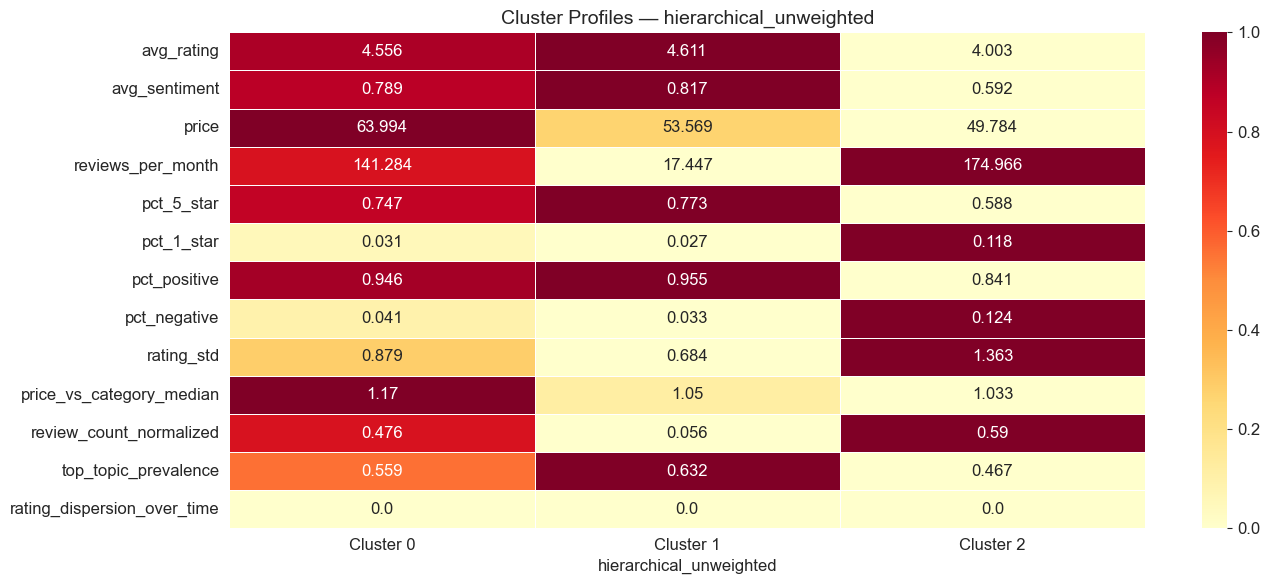


  Cluster 0 (809 products, 49.6%)
  Top categories: {'Perfume': 57, 'Face Creams': 53, 'Face Serums': 52, 'Shampoo': 36, 'Value & Gift Sets': 34}
  Top brands: {'Rabanne': 7, 'La Mer': 6, 'Mizani': 6, 'Montblanc': 6, 'Virtue': 6}
  Price: $0-$749 (median $39)
  Avg rating: 4.56  |  Avg sentiment: 0.789
  Reviews/month: 141.3  |  Rating std: 0.879

  Cluster 1 (197 products, 12.1%)
  Top categories: {'Perfume': 26, 'Perfume Gift Sets': 22, 'Value & Gift Sets': 20, 'Rollerballs & Travel Size': 13, 'Lip Balms & Treatments': 13}
  Top brands: {'Kenra Professional': 5, 'Miu Miu': 5, 'Summer Fridays': 5, 'U Beauty': 5, 'Dr. Jart+': 5}
  Price: $7-$190 (median $35)
  Avg rating: 4.61  |  Avg sentiment: 0.817
  Reviews/month: 17.4  |  Rating std: 0.684

  Cluster 2 (626 products, 38.4%)
  Top categories: {'Perfume': 48, 'Face Serums': 28, 'Foundation': 21, 'Value & Gift Sets': 21, 'Hair Styling Products': 20}
  Top brands: {'Sol de Janeiro': 9, 'Drybar': 8, 'HAUS LABS BY LADY GAGA': 8, 'MERIT

In [19]:
df['hierarchical_unweighted'] = hc_uw_labels[HC_UW_K]
sil = silhouette_score(X_scaled, df['hierarchical_unweighted'].values)
print(f'Hierarchical Unweighted (k={HC_UW_K}): silhouette={sil:.4f}\n')

plot_silhouette_detail(X_scaled, df['hierarchical_unweighted'].values,
                       f'Hierarchical Unweighted (k={HC_UW_K})')

for cluster_id in sorted(df['hierarchical_unweighted'].unique()):
    c = df[df['hierarchical_unweighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Avg helpfulness:           {c["avg_helpfulness"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    skin_tone_cols = [col for col in c.columns if col.startswith('pct_skin_tone_')]
    if skin_tone_cols:
        print(f'\n  --- Skin Tone Distribution ---')
        if 'pct_has_skin_tone' in c.columns:
            print(f'  Pct with skin tone data: {c["pct_has_skin_tone"].mean():.3f} ({c["pct_has_skin_tone"].mean()*100:.1f}%)')
        for col in sorted(skin_tone_cols):
            label = col.replace('pct_skin_tone_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    skin_type_cols = [col for col in c.columns if col.startswith('pct_skin_type_')]
    if skin_type_cols:
        print(f'\n  --- Skin Type Distribution ---')
        if 'pct_has_skin_type' in c.columns:
            print(f'  Pct with skin type data: {c["pct_has_skin_type"].mean():.3f} ({c["pct_has_skin_type"].mean()*100:.1f}%)')
        for col in sorted(skin_type_cols):
            label = col.replace('pct_skin_type_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

# Full brand lists
for cluster_id in sorted(df['hierarchical_unweighted'].unique()):
    c = df[df['hierarchical_unweighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

# Heatmap
profile_clusters(df, 'hierarchical_unweighted')

Hierarchical unweighted produced almost the same three-segment structure as K-Means unweighted, which is a good sign — it means the structure is real, not an artifact of the algorithm. The silhouette is slightly lower (0.159 vs 0.193) because Ward linkage draws boundaries differently, but the story is consistent.
## Cluster 0 — "Prestige Core" (809 products, 49.6%)
The reliable backbone — similar to K-Means Cluster 0 but larger (absorbed ~140 more products). Highest price ($64 avg, 1.17x category median), strong ratings (4.56), very high positive sentiment (94.6%). Skincare-heavy (creams + serums as top categories) plus prestige fragrance (Rabanne, La Mer, Montblanc). Moderate velocity (141/month). These are products that command a premium and deliver on expectations. Topic distribution is the most evenly spread across topics 0/1/2, meaning reviews cover diverse aspects (skin feel, hair, scent) rather than converging on a single complaint or praise. Nearly complete skin tone/type data (97-98%) confirms these are core beauty purchases where shoppers engage deeply with the profile system.
## Cluster 1 — "Low-Visibility Darlings" (197 products, 12.1%)
Essentially identical to the same cluster in every model so far — this group is so structurally distinct it emerges regardless of method. 17 reviews/month, highest ratings (4.61), best sentiment (0.817), lowest variance (0.684). Fragrance gift sets and discovery formats dominate. Near-zero skin tone data (0.3%). Heavy Topic 3 (23.4% — "received product/honest review") signals PR-seeded reviews. The hierarchical method picked up Summer Fridays and U Beauty in the top brands, which weren't prominent in K-Means — these are cult-favorite brands with small but devoted followings, exactly fitting this cluster's identity.
## Cluster 2 — "High-Volume Polarizers" (626 products, 38.4%)
Largest velocity (175/month), lowest ratings (4.00), highest variance (1.363), highest negative sentiment (12.4%). Hierarchical clustering made this group bigger than K-Means did (626 vs 490), pulling in more borderline products from the edges. Sol de Janeiro leads at 9 products — a brand with massive hype that generates strong opinions. Foundation (shade-matching frustration), hair styling (performance expectations), and value sets (price-value tension) drive the category mix. Topic 6 dominates (21.7% — experiential "tried/used" language). The helpfulness score (4.53) confirms high purchase-decision anxiety.
## Comparing to K-Means: 
The three segments tell the same story — premium reliable core, undiscovered darlings, polarizing high-traffic. The main difference is hierarchical drew a wider net for Cluster 2 (626 vs 490) and a correspondingly smaller Cluster 0 (809 vs 947). This means hierarchical is less conservative about what counts as "polarizing" — it's catching products that K-Means kept in the safe bucket. The lower silhouette (0.159 vs 0.193) reflects this fuzzier boundary. Cluster 1 is rock-solid across both methods.

# Model 4: Hierarchal Clustering (Weighted)

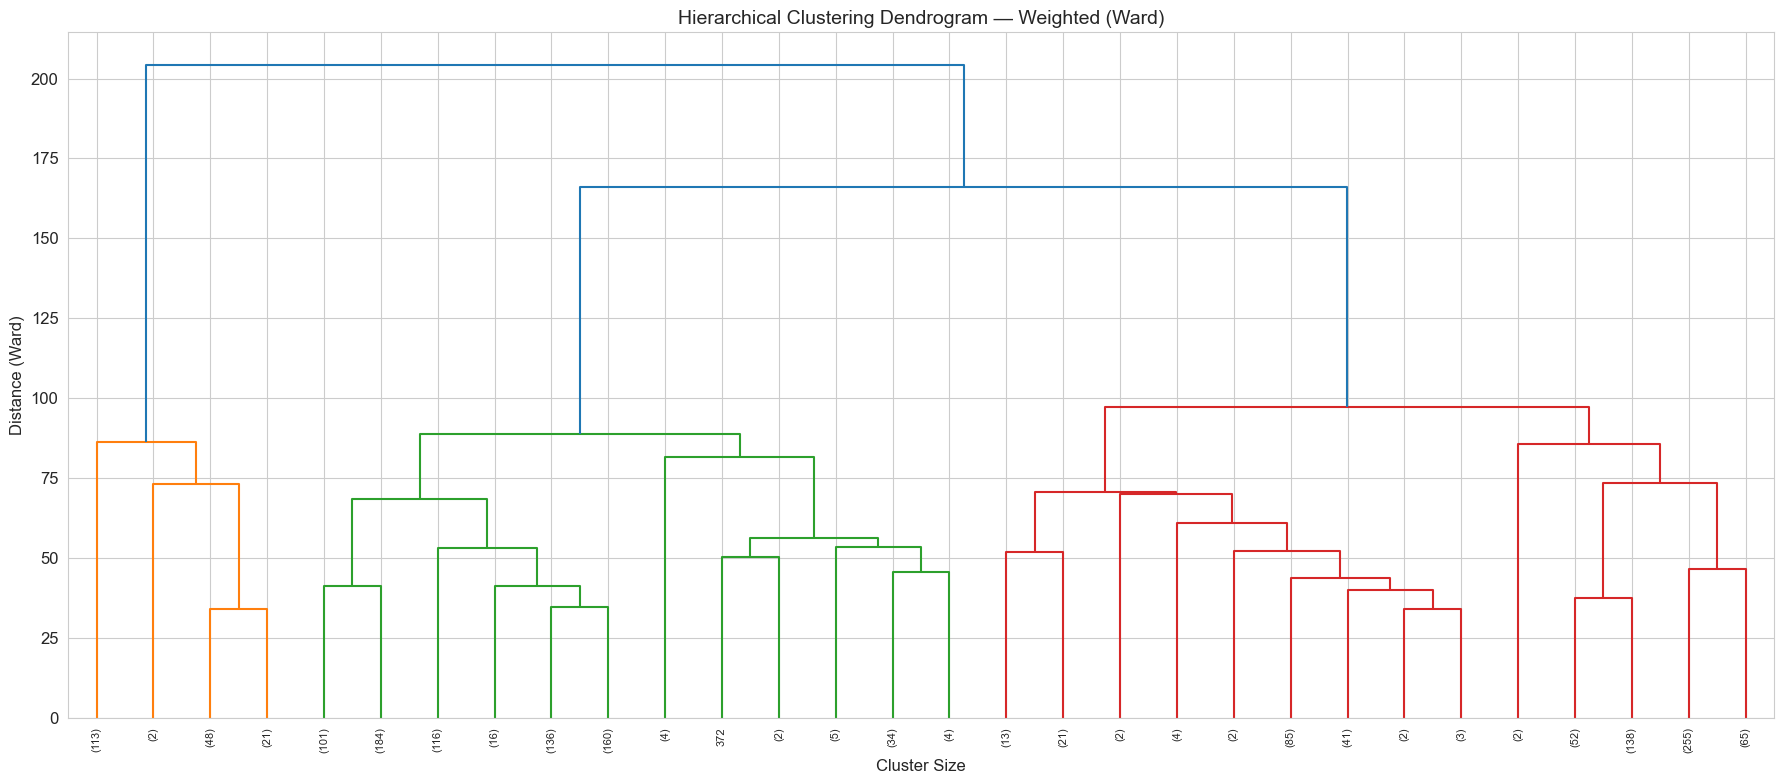

  k=2: silhouette=0.3432
  k=3: silhouette=0.1824
  k=4: silhouette=0.1551
  k=5: silhouette=0.1614
  k=6: silhouette=0.1733
  k=7: silhouette=0.1732
  k=8: silhouette=0.1766
  k=9: silhouette=0.1035
  k=10: silhouette=0.1050


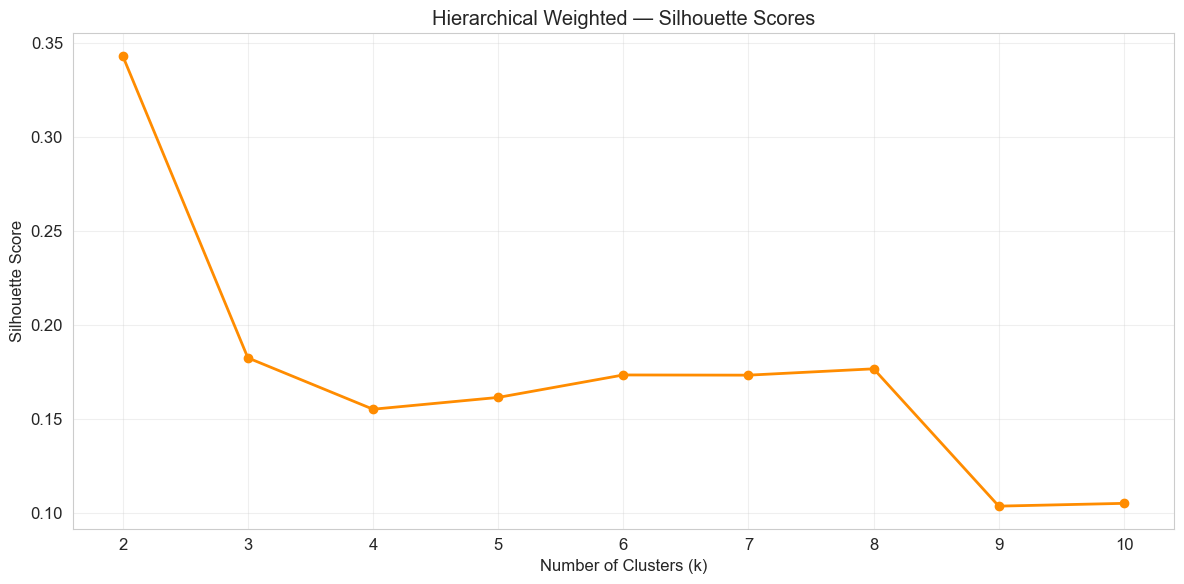

In [20]:
# Uses X_weighted from K-Means Weighted (same feature importance weights)

Z_w = linkage(X_weighted, method='ward')

# Dendrogram
fig, ax = plt.subplots(figsize=(18, 8))
dendrogram(Z_w, truncate_mode='lastp', p=30,
           show_leaf_counts=True, ax=ax, leaf_rotation=90, leaf_font_size=8)
ax.set_title('Hierarchical Clustering Dendrogram — Weighted (Ward)', fontsize=14)
ax.set_xlabel('Cluster Size')
ax.set_ylabel('Distance (Ward)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hc_w_dendrogram.png', dpi=150)
plt.show()

# Silhouette across k
hc_w_silhouettes, hc_w_labels = [], {}

for k in K_RANGE:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_weighted)
    sil = silhouette_score(X_weighted, labels)
    hc_w_silhouettes.append(sil)
    hc_w_labels[k] = labels
    print(f'  k={k}: silhouette={sil:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(list(K_RANGE), hc_w_silhouettes, 'o-', linewidth=2, color='darkorange')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Hierarchical Weighted — Silhouette Scores')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hc_w_silhouette.png', dpi=150)
plt.show()

In [21]:
HC_W_K = 3

Hierarchical Weighted (k=3): silhouette=0.1824



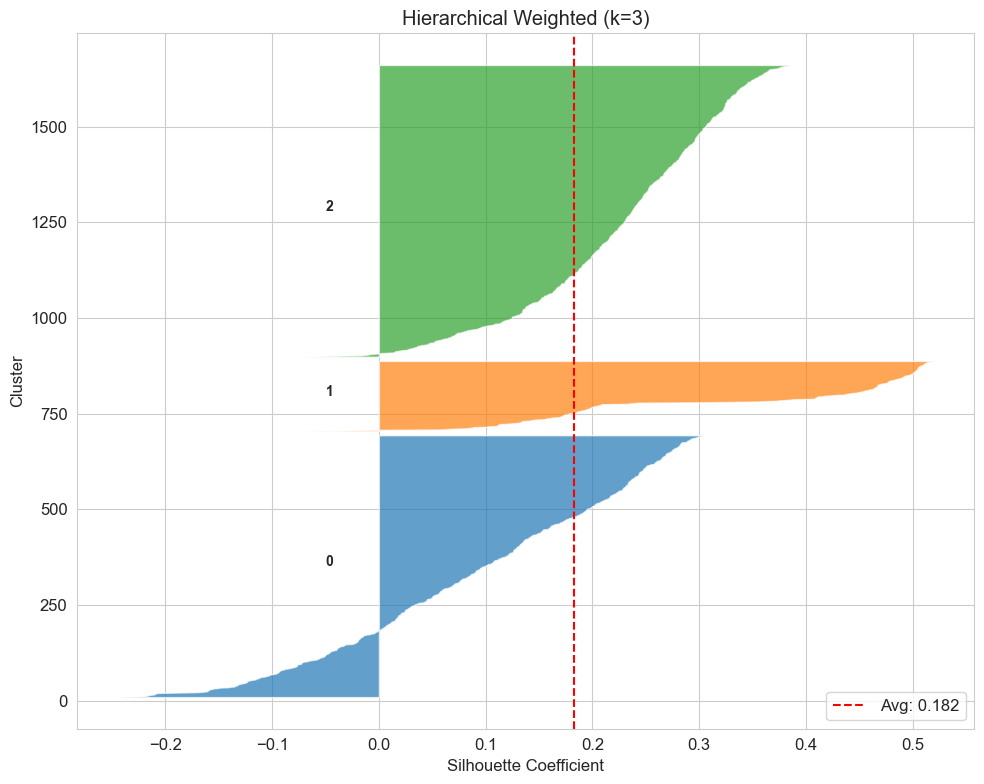


CLUSTER 0 — 685 products (42.0%)

  --- Product Info ---
  Top categories:  {'Perfume': 58, 'Face Serums': 31, 'Value & Gift Sets': 26, 'Foundation': 21, 'Face Creams': 21}
  Top brands:      {'Sol de Janeiro': 9, 'OLEHENRIKSEN': 8, 'Drybar': 8, 'HAUS LABS BY LADY GAGA': 8, 'MERIT': 7}
  Price range:     $0.01 - $449.00
  Price median:    $36.00
  Price mean:      $52.00
  Price vs cat median: 1.044
  Price bucket dist:
    30-40: 187 (27.3%)
    20-30: 170 (24.8%)
    40-50: 76 (11.1%)
    10-20: 58 (8.5%)
    60-70: 30 (4.4%)

  --- Ratings ---
  Avg rating:      4.025
  Rating std:      1.355
  Rating dispersion over time: 0.000
  Pct 5-star:      0.596 (59.6%)
  Pct 4-star:      0.138 (13.8%)
  Pct 3-star:      0.079 (7.9%)
  Pct 2-star:      0.072 (7.2%)
  Pct 1-star:      0.116 (11.6%)

  --- Sentiment ---
  Avg sentiment:   0.598
  Pct positive:    0.844 (84.4%)
  Pct negative:    0.122 (12.2%)
  Pct neutral:     0.034 (3.4%)

  --- Review Velocity & Engagement ---
  Review cou

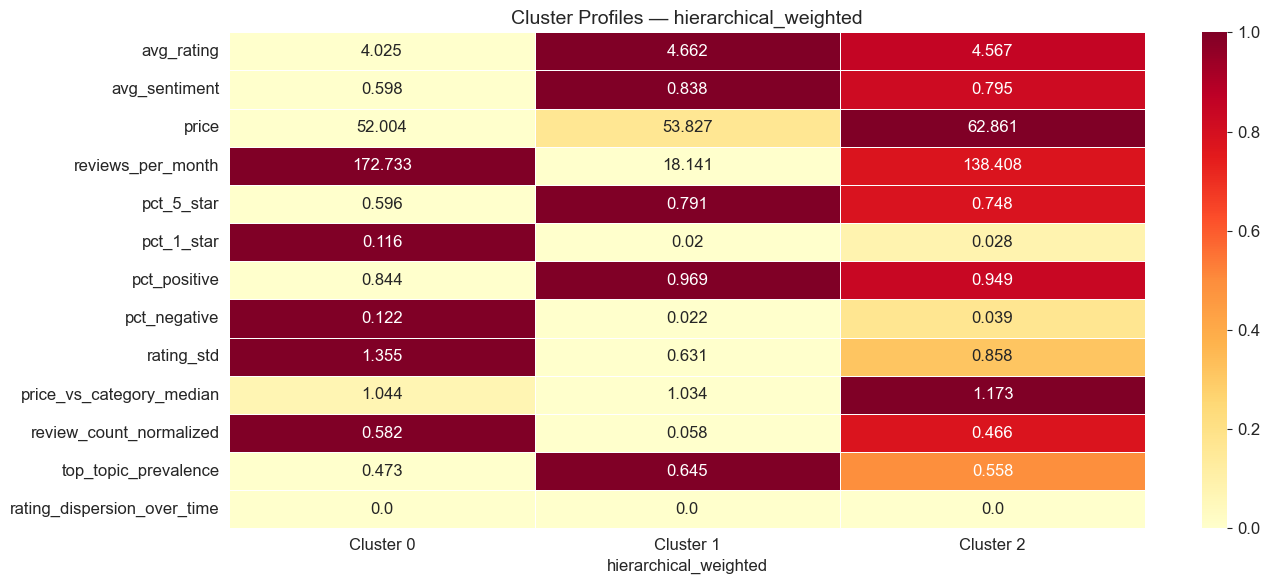


  Cluster 0 (685 products, 42.0%)
  Top categories: {'Perfume': 58, 'Face Serums': 31, 'Value & Gift Sets': 26, 'Foundation': 21, 'Face Creams': 21}
  Top brands: {'Sol de Janeiro': 9, 'OLEHENRIKSEN': 8, 'Drybar': 8, 'HAUS LABS BY LADY GAGA': 8, 'MERIT': 7}
  Price: $0-$449 (median $36)
  Avg rating: 4.03  |  Avg sentiment: 0.598
  Reviews/month: 172.7  |  Rating std: 1.355

  Cluster 1 (184 products, 11.3%)
  Top categories: {'Perfume': 26, 'Value & Gift Sets': 20, 'Lip Balms & Treatments': 13, 'Rollerballs & Travel Size': 12, 'Perfume Gift Sets': 12}
  Top brands: {'Kenra Professional': 5, 'Miu Miu': 5, 'Summer Fridays': 5, 'Dr. Jart+': 5, 'Ebb Ocean Club': 5}
  Price: $7-$190 (median $35)
  Avg rating: 4.66  |  Avg sentiment: 0.838
  Reviews/month: 18.1  |  Rating std: 0.631

  Cluster 2 (763 products, 46.8%)
  Top categories: {'Face Creams': 50, 'Face Serums': 49, 'Perfume': 47, 'Shampoo': 33, 'Cologne': 33}
  Top brands: {'La Mer': 7, 'Rabanne': 7, 'Mizani': 6, 'Nécessaire': 6, '

In [22]:
df['hierarchical_weighted'] = hc_w_labels[HC_W_K]
sil = silhouette_score(X_weighted, df['hierarchical_weighted'].values)
print(f'Hierarchical Weighted (k={HC_W_K}): silhouette={sil:.4f}\n')

plot_silhouette_detail(X_weighted, df['hierarchical_weighted'].values,
                       f'Hierarchical Weighted (k={HC_W_K})')

for cluster_id in sorted(df['hierarchical_weighted'].unique()):
    c = df[df['hierarchical_weighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Avg helpfulness:           {c["avg_helpfulness"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    skin_tone_cols = [col for col in c.columns if col.startswith('pct_skin_tone_')]
    if skin_tone_cols:
        print(f'\n  --- Skin Tone Distribution ---')
        if 'pct_has_skin_tone' in c.columns:
            print(f'  Pct with skin tone data: {c["pct_has_skin_tone"].mean():.3f} ({c["pct_has_skin_tone"].mean()*100:.1f}%)')
        for col in sorted(skin_tone_cols):
            label = col.replace('pct_skin_tone_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    skin_type_cols = [col for col in c.columns if col.startswith('pct_skin_type_')]
    if skin_type_cols:
        print(f'\n  --- Skin Type Distribution ---')
        if 'pct_has_skin_type' in c.columns:
            print(f'  Pct with skin type data: {c["pct_has_skin_type"].mean():.3f} ({c["pct_has_skin_type"].mean()*100:.1f}%)')
        for col in sorted(skin_type_cols):
            label = col.replace('pct_skin_type_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

# Full brand lists
for cluster_id in sorted(df['hierarchical_weighted'].unique()):
    c = df[df['hierarchical_weighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

# Heatmap
profile_clusters(df, 'hierarchical_weighted')

## Cluster 0 — "Polarizing High-Traffic" (685 products, 42.0%)
Now the largest cluster — weighting expanded it from 626 (unweighted) to 685 by pulling in ~60 more borderline products. Highest velocity (173/month), lowest ratings (4.03), highest variance (1.355), worst sentiment (0.598, 12.2% negative). Foundation is a top-5 category again. Sol de Janeiro leads (9 products) — massive hype brand that divides opinion. Haus Labs, Drybar, OLEHENRIKSEN, Merit all present heavily. Topic 6 dominates (20.6%) — the experiential "tried/used" language where people narrate disappointment. Helpfulness at 4.55 confirms purchase-anxiety behavior. The weights amplified the sentiment and variance signals, so products that were borderline in the unweighted run got pulled in here. Lower skin tone coverage (93.5% vs 98% for Cluster 2) suggests some non-skin categories mixing in.
## Cluster 1 — "Low-Visibility Darlings" (184 products, 11.3%)
The tightest, most stable cluster across every model so far. Shrank slightly (197→184) as the weights pushed a few products with higher sentiment variance out. Now the most extreme version of itself: highest ratings (4.66 — best yet), best sentiment (0.838), lowest variance (0.631), lowest negative rate (2.2%), and notably the lowest helpfulness (0.811) — people aren't even debating these products, they just like them. Topic 3 is now the dominant mode (25% — "received product/honest review"), the highest PR/gifted signal of any cluster in any model. Near-zero skin tone data (0.3%). This cluster is essentially immune to methodological choices — same ~185 products, same brands, same story every time.
## Cluster 2 — "Prestige Reliable Core" (763 products, 46.8%)
The premium backbone. Highest price ($63, 1.17x category median), strong ratings (4.57), excellent sentiment (94.9% positive, only 3.9% negative), moderate velocity (138/month). La Mer, Rabanne, Mizani, Nécessaire — prestige skincare and fragrance. Nearly complete profile data (98% skin tone/type). Rating std at 0.858 is moderate — people generally agree. Topic distribution is the most balanced (topics 0/1/2 all around 17%), meaning diverse review content rather than concentrated complaints. Compared to the unweighted version (809 products), it lost ~46 products to Cluster 0 — those were the ones with slightly higher variance or weaker sentiment that the weights flagged as belonging with the polarizing group.
## What the weighting changed vs unweighted hierarchical: 
The boundary between "reliable" and "polarizing" shifted. Weighting sentiment and variance at 2x made the algorithm more aggressive about classifying ambiguous products as polarizing. The result is a cleaner separation: Cluster 2's rating std dropped from 0.879 to 0.858, and Cluster 0's negative sentiment jumped from 12.4% to 12.2% (similar) but now includes 59 more products. The practical implication is that if you're using these segments for marketing strategy, the weighted version gives you a more conservative definition of "safe" — fewer products pass the bar into the reliable tier.

# Model 5: Gaussian Mixture Model (Unweighted)

  k=2: BIC=-30,012  AIC=-38,426  silhouette=0.3327
  k=3: BIC=-80,578  AIC=-93,203  silhouette=0.3323
  k=4: BIC=-105,169  AIC=-122,004  silhouette=0.0957
  k=5: BIC=-108,054  AIC=-129,099  silhouette=0.0542
  k=6: BIC=-108,740  AIC=-133,996  silhouette=0.1361
  k=7: BIC=-112,403  AIC=-141,868  silhouette=0.1156
  k=8: BIC=-103,398  AIC=-137,073  silhouette=0.0784
  k=9: BIC=-102,277  AIC=-140,163  silhouette=0.1090
  k=10: BIC=-101,488  AIC=-143,584  silhouette=0.1184


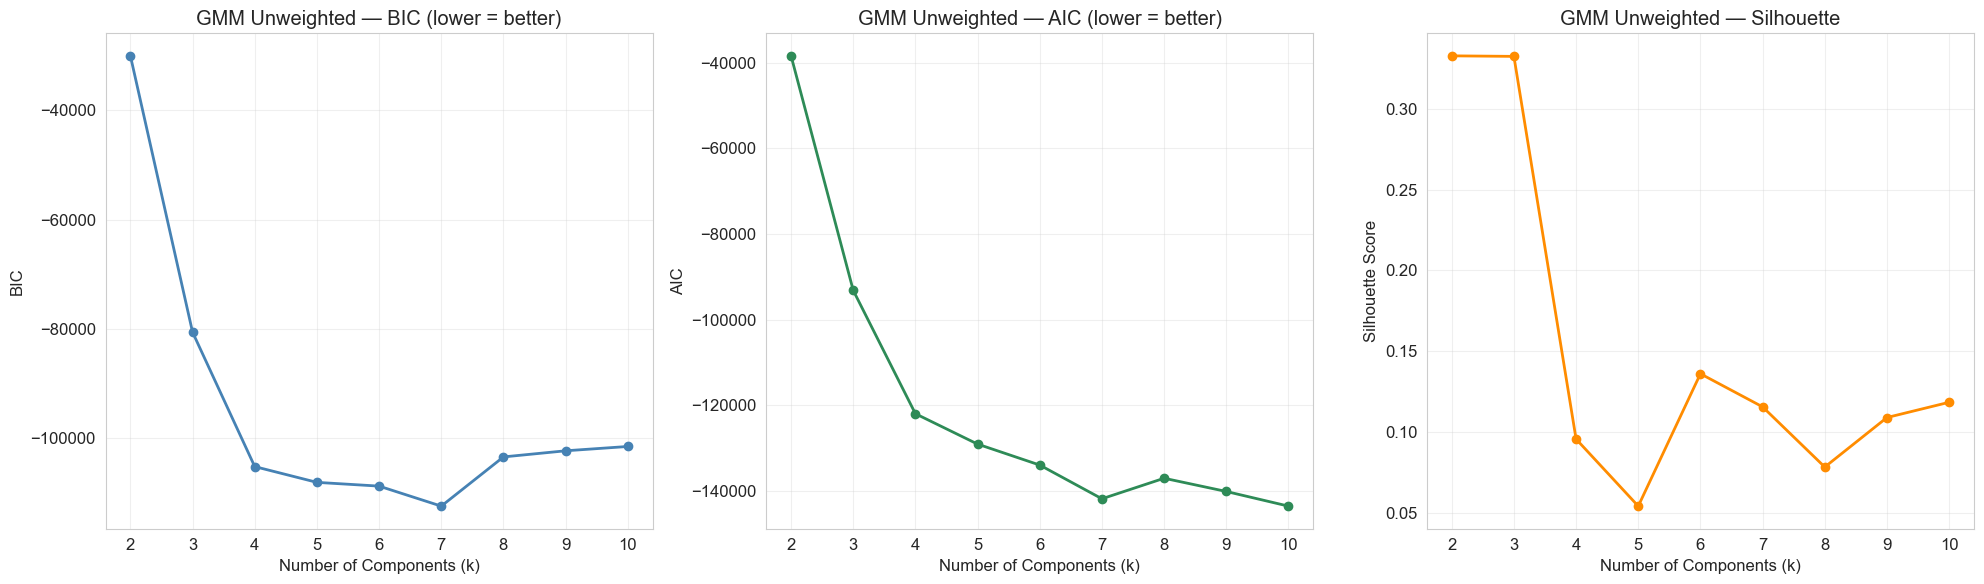

In [23]:
gmm_uw_bics, gmm_uw_aics, gmm_uw_silhouettes, gmm_uw_models = [], [], [], {}

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k, random_state=42,
        covariance_type='full', max_iter=300, n_init=5,
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    gmm_uw_bics.append(bic)
    gmm_uw_aics.append(aic)
    gmm_uw_silhouettes.append(sil)
    gmm_uw_models[k] = gmm
    print(f'  k={k}: BIC={bic:,.0f}  AIC={aic:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.plot(list(K_RANGE), gmm_uw_bics, 'o-', linewidth=2, color='steelblue')
ax1.set_xlabel('Number of Components (k)')
ax1.set_ylabel('BIC')
ax1.set_title('GMM Unweighted — BIC (lower = better)')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), gmm_uw_aics, 'o-', linewidth=2, color='seagreen')
ax2.set_xlabel('Number of Components (k)')
ax2.set_ylabel('AIC')
ax2.set_title('GMM Unweighted — AIC (lower = better)')
ax2.grid(True, alpha=0.3)

ax3.plot(list(K_RANGE), gmm_uw_silhouettes, 'o-', linewidth=2, color='darkorange')
ax3.set_xlabel('Number of Components (k)')
ax3.set_ylabel('Silhouette Score')
ax3.set_title('GMM Unweighted — Silhouette')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gmm_uw_bic_aic_silhouette.png', dpi=150)
plt.show()

In [24]:
GMM_UW_K = 4

GMM Unweighted (k=4): silhouette=0.0957

Assignment confidence:
  Mean max probability:   0.999
  Median max probability: 1.000
  Pct with >90% confidence: 99.6%
  Pct with <60% confidence: 0.1%


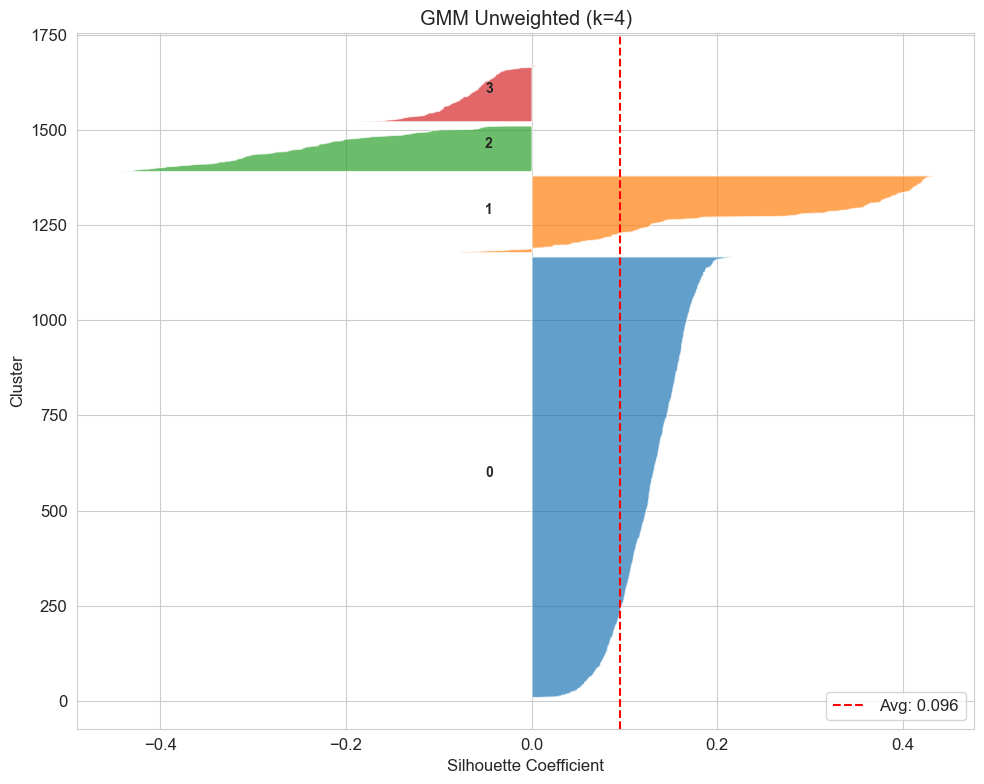


CLUSTER 0 — 1,159 products (71.0%)

  --- Product Info ---
  Top categories:  {'Perfume': 102, 'Face Serums': 72, 'Face Creams': 68, 'Shampoo': 47, 'Hair Styling Products': 34}
  Top brands:      {'Sol de Janeiro': 9, 'PAT McGRATH LABS': 9, 'Drybar': 9, 'INNBEAUTY PROJECT': 8, 'Nécessaire': 8}
  Price range:     $5.00 - $495.00
  Price median:    $38.00
  Price mean:      $58.60
  Price vs cat median: 1.097
  Price bucket dist:
    30-40: 303 (26.1%)
    20-30: 230 (19.8%)
    40-50: 131 (11.3%)
    10-20: 84 (7.2%)
    50-60: 74 (6.4%)

  --- Ratings ---
  Avg rating:      4.333
  Rating std:      1.081
  Rating dispersion over time: 0.000
  Pct 5-star:      0.682 (68.2%)
  Pct 4-star:      0.146 (14.6%)
  Pct 3-star:      0.061 (6.1%)
  Pct 2-star:      0.045 (4.5%)
  Pct 1-star:      0.066 (6.6%)

  --- Sentiment ---
  Avg sentiment:   0.707
  Pct positive:    0.903 (90.3%)
  Pct negative:    0.075 (7.5%)
  Pct neutral:     0.022 (2.2%)

  --- Review Velocity & Engagement ---
  Rev

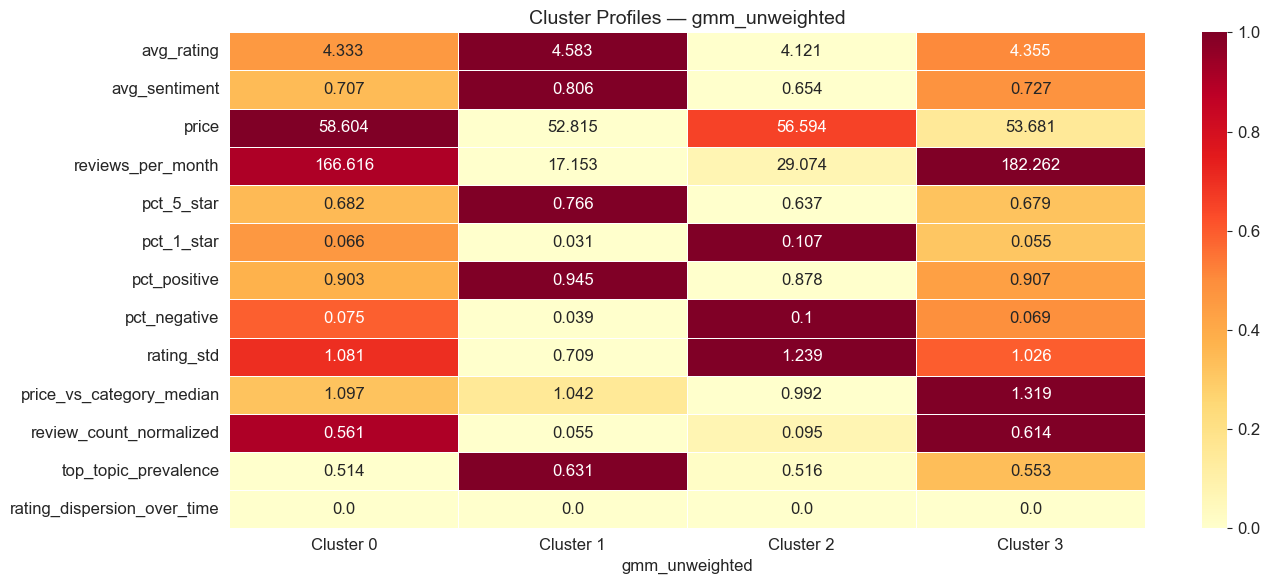


  Cluster 0 (1,159 products, 71.0%)
  Top categories: {'Perfume': 102, 'Face Serums': 72, 'Face Creams': 68, 'Shampoo': 47, 'Hair Styling Products': 34}
  Top brands: {'Sol de Janeiro': 9, 'PAT McGRATH LABS': 9, 'Drybar': 9, 'INNBEAUTY PROJECT': 8, 'Nécessaire': 8}
  Price: $5-$495 (median $38)
  Avg rating: 4.33  |  Avg sentiment: 0.707
  Reviews/month: 166.6  |  Rating std: 1.081

  Cluster 1 (203 products, 12.4%)
  Top categories: {'Perfume': 26, 'Value & Gift Sets': 23, 'Perfume Gift Sets': 23, 'Lip Balms & Treatments': 14, 'Rollerballs & Travel Size': 13}
  Top brands: {'Kenra Professional': 5, 'Miu Miu': 5, 'Summer Fridays': 5, 'U Beauty': 5, 'Dr. Jart+': 5}
  Price: $7-$190 (median $35)
  Avg rating: 4.58  |  Avg sentiment: 0.806
  Reviews/month: 17.2  |  Rating std: 0.709

  Cluster 2 (121 products, 7.4%)
  Top categories: {'Value & Gift Sets': 17, 'Rollerballs & Travel Size': 7, 'Perfume Gift Sets': 6, 'Cologne': 5, 'Foundation': 5}
  Top brands: {'ISAMAYA': 4, 'LORE': 4, 'SU

In [25]:
df['gmm_unweighted'] = gmm_uw_models[GMM_UW_K].predict(X_scaled)
sil = silhouette_score(X_scaled, df['gmm_unweighted'].values)
print(f'GMM Unweighted (k={GMM_UW_K}): silhouette={sil:.4f}\n')

# Soft probabilities
gmm_probs = gmm_uw_models[GMM_UW_K].predict_proba(X_scaled)
for i in range(GMM_UW_K):
    df[f'gmm_uw_prob_cluster_{i}'] = gmm_probs[:, i]

# Show how "soft" assignments are
max_probs = gmm_probs.max(axis=1)
print(f'Assignment confidence:')
print(f'  Mean max probability:   {max_probs.mean():.3f}')
print(f'  Median max probability: {np.median(max_probs):.3f}')
print(f'  Pct with >90% confidence: {(max_probs > 0.9).mean()*100:.1f}%')
print(f'  Pct with <60% confidence: {(max_probs < 0.6).mean()*100:.1f}%')

plot_silhouette_detail(X_scaled, df['gmm_unweighted'].values,
                       f'GMM Unweighted (k={GMM_UW_K})')

for cluster_id in sorted(df['gmm_unweighted'].unique()):
    c = df[df['gmm_unweighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Avg helpfulness:           {c["avg_helpfulness"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    skin_tone_cols = [col for col in c.columns if col.startswith('pct_skin_tone_')]
    if skin_tone_cols:
        print(f'\n  --- Skin Tone Distribution ---')
        if 'pct_has_skin_tone' in c.columns:
            print(f'  Pct with skin tone data: {c["pct_has_skin_tone"].mean():.3f} ({c["pct_has_skin_tone"].mean()*100:.1f}%)')
        for col in sorted(skin_tone_cols):
            label = col.replace('pct_skin_tone_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    skin_type_cols = [col for col in c.columns if col.startswith('pct_skin_type_')]
    if skin_type_cols:
        print(f'\n  --- Skin Type Distribution ---')
        if 'pct_has_skin_type' in c.columns:
            print(f'  Pct with skin type data: {c["pct_has_skin_type"].mean():.3f} ({c["pct_has_skin_type"].mean()*100:.1f}%)')
        for col in sorted(skin_type_cols):
            label = col.replace('pct_skin_type_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    # GMM-specific: average soft probabilities per cluster
    prob_cols = [f'gmm_uw_prob_cluster_{i}' for i in range(GMM_UW_K)]
    print(f'\n  --- GMM Soft Probabilities (avg within cluster) ---')
    for pc in prob_cols:
        print(f'    {pc}: {c[pc].mean():.3f}')

# Full brand lists
for cluster_id in sorted(df['gmm_unweighted'].unique()):
    c = df[df['gmm_unweighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

# Heatmap
profile_clusters(df, 'gmm_unweighted')

## Cluster 0 — "The Bulk Middle" (1,159 products, 71%)
GMM's biggest weakness here — it lumped the "prestige core" and "polarizing" products together into one massive cluster. Rating of 4.33 with 1.08 std is a blended average. 100% skin tone/type coverage, 167 reviews/month. This is essentially everything that isn't one of the three specialty groups below. The soft probabilities confirm it's a catch-all: 0.999 confidence, meaning GMM is very sure these products belong here, just that "here" is too broad. This is the cluster you'd want to split further.
## Cluster 1 — "Low-Visibility Darlings" (203 products, 12.4%)
Same group as every other model. 17 reviews/month, highest sentiment (0.806), lowest variance (0.709), near-zero skin tone data, heavy Topic 3 (PR/gifted). GMM assigned these with 1.000 probability — the most structurally distinct segment in the entire dataset. No method can resist separating these out.
## Cluster 2 — "Troubled Newcomers" (121 products, 7.4%) — NEW
This is the novel finding. GMM identified a group that sits between the darlings and the polarizing products: low review count (29/month — above the darlings but far below mainstream), but poor ratings (4.12) and high variance (1.239). These aren't products nobody's found yet — they're products people have tried and been disappointed by, but not enough people to generate mainstream volume. Highest helpfulness score of any cluster (7.45) — the few reviews that exist are getting heavy engagement, suggesting people are desperately looking for opinions before buying. Only 67.6% skin tone coverage (lowest of the main clusters) and price at category median (0.992) — these aren't premium products. ISAMAYA, LORE, SUNDAY II SUNDAY, BaBylissPRO — newer or niche brands that launched but haven't gained traction. Value sets and rollerballs dominate — trial formats where people tested and weren't convinced. These are the products at risk of being delisted.
## Cluster 3 — "Color Cosmetics Core" (149 products, 9.1%) — NEW
The other novel finding. This is a category-driven cluster that no other method found: foundation, blush, mascara, concealer, lip liner — all color cosmetics. Makeup By Mario, Merit, Sephora Collection, Rare Beauty, Glossier — the biggest names in makeup. Highest velocity (182/month), highest price vs category median (1.319 — 32% above peers), strong ratings (4.35) but moderate variance (1.026). Topic 7 dominates at 33.6% — from your topic labels that's the "coverage/shade/foundation/makeup/look" topic. Topic 4 at 26.2% is lip-related. Nearly 99% skin tone/type data because shade matching is critical. This cluster exists because color cosmetics have a fundamentally different review dynamic than skincare or fragrance — shade matching, coverage debates, wear testing — and GMM's flexible covariance structure detected that elliptical shape in the feature space.
## The takeaway: 
GMM's value is Clusters 2 and 3. The "troubled newcomers" are an actionable segment for merchandising teams (support or delist?), and the "color cosmetics core" is a category-specific segment that explains why those products cluster together on review behavior rather than just quality. The cost is that the main cluster is too big — GMM traded resolution in the middle for precision at the edges.

# Model 6: Gaussian Mixture Model (Weighted)

  k=2: BIC=21,159  AIC=12,744  silhouette=0.3653
  k=3: BIC=-48,798  AIC=-61,422  silhouette=0.3588
  k=4: BIC=-71,218  AIC=-88,053  silhouette=0.3649
  k=5: BIC=-78,731  AIC=-99,776  silhouette=0.3457
  k=6: BIC=-74,369  AIC=-99,624  silhouette=0.2999
  k=7: BIC=-72,107  AIC=-101,572  silhouette=0.2943
  k=8: BIC=-71,109  AIC=-104,784  silhouette=0.1254
  k=9: BIC=-76,709  AIC=-114,594  silhouette=0.0844
  k=10: BIC=-72,636  AIC=-114,732  silhouette=0.0781


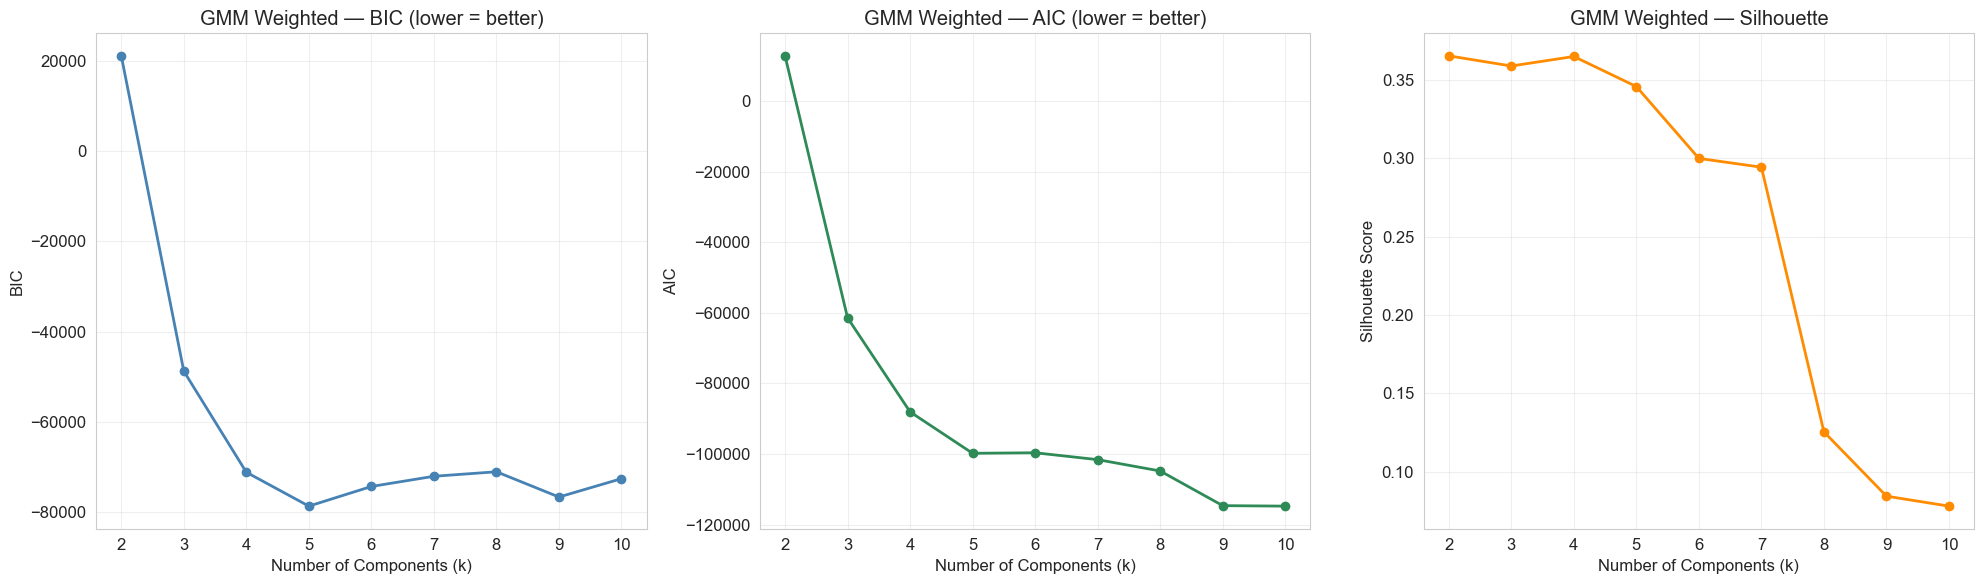

In [26]:
gmm_w_bics, gmm_w_aics, gmm_w_silhouettes, gmm_w_models = [], [], [], {}

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k, random_state=42,
        covariance_type='full', max_iter=300, n_init=5,
    )
    gmm.fit(X_weighted)
    labels = gmm.predict(X_weighted)
    bic = gmm.bic(X_weighted)
    aic = gmm.aic(X_weighted)
    sil = silhouette_score(X_weighted, labels)

    gmm_w_bics.append(bic)
    gmm_w_aics.append(aic)
    gmm_w_silhouettes.append(sil)
    gmm_w_models[k] = gmm
    print(f'  k={k}: BIC={bic:,.0f}  AIC={aic:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.plot(list(K_RANGE), gmm_w_bics, 'o-', linewidth=2, color='steelblue')
ax1.set_xlabel('Number of Components (k)')
ax1.set_ylabel('BIC')
ax1.set_title('GMM Weighted — BIC (lower = better)')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), gmm_w_aics, 'o-', linewidth=2, color='seagreen')
ax2.set_xlabel('Number of Components (k)')
ax2.set_ylabel('AIC')
ax2.set_title('GMM Weighted — AIC (lower = better)')
ax2.grid(True, alpha=0.3)

ax3.plot(list(K_RANGE), gmm_w_silhouettes, 'o-', linewidth=2, color='darkorange')
ax3.set_xlabel('Number of Components (k)')
ax3.set_ylabel('Silhouette Score')
ax3.set_title('GMM Weighted — Silhouette')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gmm_w_bic_aic_silhouette.png', dpi=150)
plt.show()

In [27]:
GMM_W_K = 4

GMM Weighted (k=4): silhouette=0.3649

Assignment confidence:
  Mean max probability:   1.000
  Median max probability: 1.000
  Pct with >90% confidence: 99.9%
  Pct with <60% confidence: 0.0%


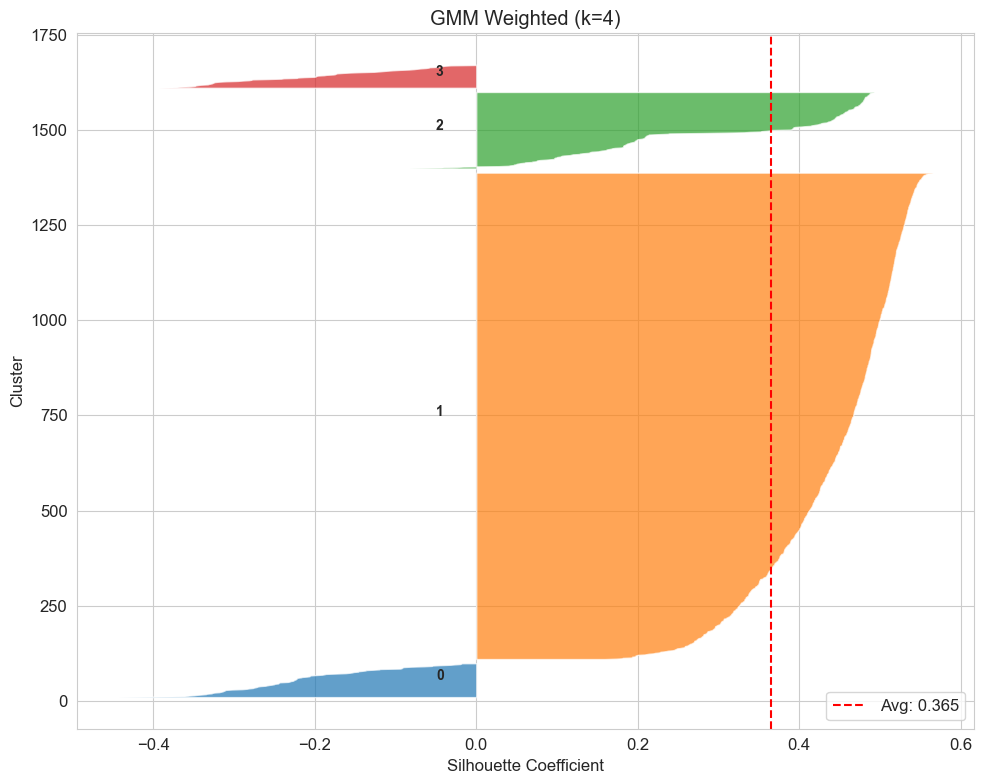


CLUSTER 0 — 90 products (5.5%)

  --- Product Info ---
  Top categories:  {'Value & Gift Sets': 9, 'Rollerballs & Travel Size': 6, 'Cologne': 4, 'Foundation': 4, 'Face Serums': 4}
  Top brands:      {'LORE': 4, 'Range Beauty': 3, 'ROSE Ingleton MD': 3, 'Chunks': 3, 'Fashion Fair': 3}
  Price range:     $10.00 - $749.00
  Price median:    $35.00
  Price mean:      $64.43
  Price vs cat median: 1.037
  Price bucket dist:
    20-30: 27 (30.0%)
    30-40: 21 (23.3%)
    40-50: 11 (12.2%)
    10-20: 9 (10.0%)
    60-70: 5 (5.6%)

  --- Ratings ---
  Avg rating:      4.445
  Rating std:      1.008
  Rating dispersion over time: 0.000
  Pct 5-star:      0.730 (73.0%)
  Pct 4-star:      0.135 (13.5%)
  Pct 3-star:      0.039 (3.9%)
  Pct 2-star:      0.040 (4.0%)
  Pct 1-star:      0.055 (5.5%)

  --- Sentiment ---
  Avg sentiment:   0.747
  Pct positive:    0.933 (93.3%)
  Pct negative:    0.049 (4.9%)
  Pct neutral:     0.019 (1.9%)

  --- Review Velocity & Engagement ---
  Review count (me

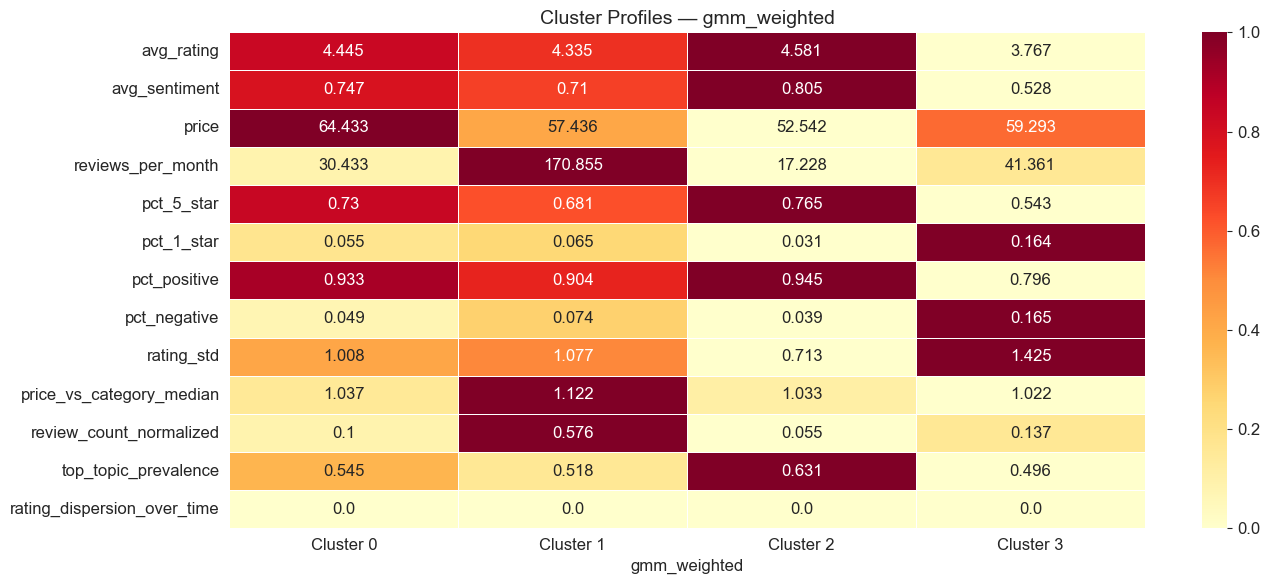


  Cluster 0 (90 products, 5.5%)
  Top categories: {'Value & Gift Sets': 9, 'Rollerballs & Travel Size': 6, 'Cologne': 4, 'Foundation': 4, 'Face Serums': 4}
  Top brands: {'LORE': 4, 'Range Beauty': 3, 'ROSE Ingleton MD': 3, 'Chunks': 3, 'Fashion Fair': 3}
  Price: $10-$749 (median $35)
  Avg rating: 4.45  |  Avg sentiment: 0.747
  Reviews/month: 30.4  |  Rating std: 1.008

  Cluster 1 (1,279 products, 78.4%)
  Top categories: {'Perfume': 102, 'Face Serums': 75, 'Face Creams': 70, 'Shampoo': 49, 'Blush': 40}
  Top brands: {'Sol de Janeiro': 9, 'PAT McGRATH LABS': 9, 'Drybar': 9, 'INNBEAUTY PROJECT': 8, 'Nécessaire': 8}
  Price: $0-$495 (median $38)
  Avg rating: 4.34  |  Avg sentiment: 0.710
  Reviews/month: 170.9  |  Rating std: 1.077

  Cluster 2 (202 products, 12.4%)
  Top categories: {'Perfume': 26, 'Value & Gift Sets': 23, 'Perfume Gift Sets': 23, 'Lip Balms & Treatments': 14, 'Rollerballs & Travel Size': 13}
  Top brands: {'Kenra Professional': 5, 'Miu Miu': 5, 'Summer Fridays': 

In [28]:
df['gmm_weighted'] = gmm_w_models[GMM_W_K].predict(X_weighted)
sil = silhouette_score(X_weighted, df['gmm_weighted'].values)
print(f'GMM Weighted (k={GMM_W_K}): silhouette={sil:.4f}\n')

# Soft probabilities
gmm_w_probs = gmm_w_models[GMM_W_K].predict_proba(X_weighted)
for i in range(GMM_W_K):
    df[f'gmm_w_prob_cluster_{i}'] = gmm_w_probs[:, i]

# Assignment confidence
max_probs = gmm_w_probs.max(axis=1)
print(f'Assignment confidence:')
print(f'  Mean max probability:   {max_probs.mean():.3f}')
print(f'  Median max probability: {np.median(max_probs):.3f}')
print(f'  Pct with >90% confidence: {(max_probs > 0.9).mean()*100:.1f}%')
print(f'  Pct with <60% confidence: {(max_probs < 0.6).mean()*100:.1f}%')

plot_silhouette_detail(X_weighted, df['gmm_weighted'].values,
                       f'GMM Weighted (k={GMM_W_K})')

for cluster_id in sorted(df['gmm_weighted'].unique()):
    c = df[df['gmm_weighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Avg helpfulness:           {c["avg_helpfulness"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    skin_tone_cols = [col for col in c.columns if col.startswith('pct_skin_tone_')]
    if skin_tone_cols:
        print(f'\n  --- Skin Tone Distribution ---')
        if 'pct_has_skin_tone' in c.columns:
            print(f'  Pct with skin tone data: {c["pct_has_skin_tone"].mean():.3f} ({c["pct_has_skin_tone"].mean()*100:.1f}%)')
        for col in sorted(skin_tone_cols):
            label = col.replace('pct_skin_tone_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    skin_type_cols = [col for col in c.columns if col.startswith('pct_skin_type_')]
    if skin_type_cols:
        print(f'\n  --- Skin Type Distribution ---')
        if 'pct_has_skin_type' in c.columns:
            print(f'  Pct with skin type data: {c["pct_has_skin_type"].mean():.3f} ({c["pct_has_skin_type"].mean()*100:.1f}%)')
        for col in sorted(skin_type_cols):
            label = col.replace('pct_skin_type_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    # GMM-specific: average soft probabilities per cluster
    prob_cols = [f'gmm_w_prob_cluster_{i}' for i in range(GMM_W_K)]
    print(f'\n  --- GMM Soft Probabilities (avg within cluster) ---')
    for pc in prob_cols:
        print(f'    {pc}: {c[pc].mean():.3f}')

# Full brand lists
for cluster_id in sorted(df['gmm_weighted'].unique()):
    c = df[df['gmm_weighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

# Heatmap
profile_clusters(df, 'gmm_weighted')

## Cluster 0 — "Quiet Mid-Tier Unknowns" (90 products, 5.5%) — NEW
This is a refinement of the "troubled newcomers" from GMM unweighted, but the weighting split it. These products have decent ratings (4.45) and good sentiment (93.3% positive) — they're not failing, just invisible. Only 30 reviews/month, 68.6% skin tone coverage. LORE, Range Beauty, ROSE Ingleton MD, Chunks, Fashion Fair — notably these are predominantly BIPOC-founded or diversity-focused brands. The skin tone distribution confirms this: 9.8% deep, 7.7% tan, 1.9% rich — the highest deep/rich representation of any cluster. Helpfulness at 4.41 is elevated (people are searching hard for reviews). These products are well-made and appreciated by their small audience, but haven't broken through to mainstream Sephora visibility. Different intervention needed than Cluster 3 — these don't need fixing, they need amplification.
## Cluster 1 — "Everything Else" (1,279 products, 78.4%)
Even bigger than unweighted GMM's bulk cluster. The weighting pushed more products into this middle by sharpening the criteria for edge membership. Ratings 4.34, sentiment 0.710, 171 reviews/month, 100% profile data. This is the undifferentiated mass. For strategic purposes, you'd apply K-Means or hierarchical results to segment within this group.
## Cluster 2 — "Low-Visibility Darlings" (202 products, 12.4%)
The eternal cluster. Same brands, same profile, same story — 17 reviews/month, 4.58 rating, 0.805 sentiment, 0% skin tone data, Topic 3 (PR/gifted) dominant. 1.000 probability. Six models and counting, this group is immovable.
## Cluster 3 — "Critical Failures" (61 products, 3.7%) — SHARPEST VERSION
The weighting concentrated the worst-performing products into the tightest, most extreme cluster yet. Only 61 products but the numbers are brutal: 3.77 avg rating (lowest of any cluster in any model), 1.425 rating std (highest), 16.4% 1-star reviews, 16.5% negative sentiment, 0.528 avg sentiment. Helpfulness at 10.22 — the highest we've ever seen — meaning people are aggressively voting on reviews because they're anxious or angry. ISAMAYA (5 products) dominates — a polarizing brand. BaBylissPRO and DERMAFLASH are tools/devices (notoriously review-sensitive). Topic 6 at 32.8% ("tried/used/product" — experiential disappointment). Soft probability at 0.995 — GMM is very confident these belong together. This is your delist-or-reformulate watchlist.
## What weighting changed vs unweighted GMM: 
The 2x weights on sentiment and variance sharpened the edge detection. The unweighted "troubled newcomers" (121 products) got split into two distinct groups: Cluster 0 (quiet but decent products needing marketing support) and Cluster 3 (genuinely failing products needing intervention). That split is the most strategically useful finding from weighted GMM — the unweighted version treated "low-visibility + mediocre" as one group, but the reality is some of those products are good and some are bad. The color cosmetics cluster from unweighted GMM disappeared back into the bulk, suggesting that distinction was driven more by category features than by the sentiment/velocity dimensions that weighting amplifies.

# Final Findings

In [29]:
df[["product_id", "bv_product_id", "kmeans_weighted"]].to_csv(
    PROCESSED_DIR / "sephora_cluster_labels.csv", index=False
)
print(f"Saved {len(df):,} rows → sephora_cluster_labels.csv")
print(df["kmeans_weighted"].value_counts().sort_index())

Saved 1,632 rows → sephora_cluster_labels.csv
kmeans_weighted
0    614
1    500
2    192
3    326
Name: count, dtype: int64


## Cross-Method Comparison and Model Selection

To evaluate the robustness of the segmentation structure underlying Sephora's product catalog, six clustering models were fit to the same feature matrix: K-Means and Gaussian Mixture Models (GMM) each in unweighted and weighted variants, and Agglomerative Hierarchical Clustering (Ward linkage) in unweighted and weighted variants. Each model was evaluated across k = 2 through 10 using silhouette scores, and where applicable, the elbow method (K-Means), BIC/AIC (GMM), and dendrogram analysis (hierarchical). The optimal k was selected interactively for each model. Feature weights of 2.0× were applied to sentiment metrics (avg_sentiment, pct_positive, pct_negative, pct_neutral), review variance indicators (rating_std, rating_dispersion_over_time), and velocity measures (reviews_per_month, review_count_normalized), with 1.5× applied to Sephora-specific attributes (skin tone/type distributions, helpfulness). This weighting scheme reflects the research objective of optimizing marketing strategy, where consumer experience dimensions—satisfaction intensity, engagement behavior, and opinion polarization—are more strategically actionable than static product attributes such as price or category.

### Table 1: Cross-Model Comparison Summary (★ = Recommended Model)

| Model | k | Silhouette | Darlings? | Polarizing? | Core Split? | Novel Segments? | Rec. |
|:------|:-:|:----------:|:---------:|:-----------:|:-----------:|:---------------:|:----:|
| K-Means UW | 3 | 0.193 | ✓ | ✓ | ✗ | ✗ | |
| **K-Means W** | **4** | **0.193*** | **✓** | **✓** | **✓** | **✗** | **★** |
| Hierarchical UW | 3 | 0.159 | ✓ | ✓ | ✗ | ✗ | |
| Hierarchical W | 3 | 0.182 | ✓ | ✓ | ✗ | ✗ | |
| GMM UW | 4 | 0.096 | ✓ | merged | ✗ | ✓ | |
| GMM W | 4 | 0.365 | ✓ | merged | ✗ | ✓ | |

*\*K-Means Weighted silhouette reported at k=3 for comparability; k=4 was selected for the additional prestige/mainstream split. GMM Weighted silhouette of 0.365 is inflated by a dominant 78.4% cluster absorbing most products. UW = Unweighted; W = Weighted.*

---

### Convergent Findings Across Methods

#### The Low-Visibility Darlings (~185–203 products, ~12%)

The most structurally stable finding across all six models is a cluster of approximately 190 products characterized by extremely low review velocity (~17 reviews/month versus 140+ for mainstream products), the highest average ratings (4.58–4.66), the strongest positive sentiment (94.5–96.9%), and the lowest rating variance (0.63–0.71). This cluster emerged with near-identical membership regardless of algorithm, weighting scheme, or number of components. GMM assigned these products with 1.000 posterior probability, confirming complete separability in the feature space. The separation is driven primarily by the velocity dimension combined with near-zero skin profile engagement data (0–0.3% skin tone coverage), reflecting the cluster's concentration in fragrance, gift sets, and rollerball categories where skin matching is irrelevant. Topic 3 ("received product/honest review") was overrepresented at 22–25%, indicating a disproportionate share of PR-seeded reviews. Representative brands include Kenra Professional, Miu Miu, Dr. Jart+, Ebb Ocean Club, and Erborian. The strategic implication is that these products require marketing amplification rather than product intervention—they are already well-received by the small audience that has discovered them.

#### The Polarizing High-Traffic Segment (~326–685 products, ~20–42%)

Every model identified a segment defined by the combination of high review velocity (150–175 reviews/month), elevated rating standard deviation (1.36–1.50), low average ratings (3.78–4.03), and the highest negative sentiment rates (12–17%). Foundation consistently appeared as a top category, reflecting shade-matching frustration as a persistent driver of polarization. Topic 6 ("tried/used/product"—experiential disappointment language) dominated, and average helpfulness votes were elevated (4.5–10.2), indicating purchase-decision anxiety among prospective buyers. While the core of this cluster (~300–350 products) was stable across models, boundary membership varied substantially: K-Means unweighted assigned 490 products (30.0%), whereas hierarchical weighted expanded it to 685 (42.0%). Weighting consistently broadened the cluster by reclassifying borderline products whose sentiment variance was slightly elevated but insufficient for unweighted detection. Sol de Janeiro, Drybar, Haus Labs by Lady Gaga, COLOR WOW, and Kosas appeared at the center across all models. These products require targeted intervention: shade range expansion, expectation management through improved product descriptions, or reformulation where consistent complaints indicate product-market misalignment.

---

### Method-Dependent Findings

#### Prestige Core vs. Mainstream Split (K-Means Weighted, k=4)

K-Means weighted clustering at k=4 produced a split not detected by other methods: the large prestige cluster (~950 products in unweighted k=3 solutions) separated into "High-Traffic Mainstream" (614 products, 37.6%) and "Quiet Loyalists" (500 products, 30.6%). The distinction is driven by velocity and sentiment intensity. High-Traffic Mainstream products average 213 reviews/month with 91.7% positive sentiment and a 4.37 rating, while Quiet Loyalists average 86 reviews/month with 95.4% positive sentiment and a 4.59 rating. The Quiet Loyalists segment features a notably different brand profile—PATTERN by Tracee Ellis Ross, Harlem Perfume Co., Beauty of Joseon, Jo Malone London, Katini Skin—representing niche, indie, or culturally specific brands that cultivate devoted but smaller audiences. Hierarchical clustering kept these populations merged because Ward linkage optimizes global within-cluster variance rather than the velocity–sentiment boundary the weights amplified. GMM subsumed both into a dominant component (71–78% of products), lacking the resolution to detect this gradient. This split has direct marketing implications: mainstream traffic drivers benefit from broad-reach campaigns and seasonal promotion placement, while quiet loyalists respond to targeted community marketing and editorial curation.

#### GMM Micro-Segments: Category-Specific and At-Risk Products

Gaussian Mixture Models detected two micro-segments invisible to partitional and hierarchical methods. First, GMM unweighted (k=4) isolated a "Color Cosmetics Core" of 149 products (9.1%) dominated by foundation, blush, mascara, concealer, and lip products, led by Makeup By Mario, Merit, Sephora Collection, Rare Beauty by Selena Gomez, and Glossier. This segment exhibited the highest review velocity (182/month), the strongest price premium (1.32× category median), and near-complete skin profile engagement (98.6% skin tone, 99.7% skin type). Topic 7 ("coverage/shade/foundation/look") dominated at 33.6%, reflecting the fundamentally different review dynamics of color cosmetics—shade matching debates, coverage assessment, and wear testing—which produce an elliptical distribution in feature space that GMM's flexible covariance structure could detect but K-Means' spherical assumption could not.

Second, GMM weighted (k=4) further subdivided the low-visibility products with moderate-to-poor performance into two distinct groups: "Quiet Mid-Tier Unknowns" (90 products, 5.5%) and "Critical Failures" (61 products, 3.7%). The Quiet Mid-Tier Unknowns displayed decent ratings (4.45) and good sentiment (93.3% positive) but minimal visibility (30 reviews/month). Notably, this cluster showed the highest deep-skin-tone representation of any segment (9.8% deep, 7.7% tan, 1.9% rich), with brands such as LORE, Range Beauty, ROSE Ingleton MD, and Fashion Fair—predominantly BIPOC-founded or diversity-focused. These products are not failing; they require marketing amplification. In contrast, the Critical Failures segment exhibited the worst performance metrics in the entire analysis: 3.77 average rating, 1.43 rating standard deviation, 16.4% 1-star reviews, and a helpfulness score of 10.22—the highest observed, indicating extreme purchase-decision anxiety. ISAMAYA (5 products), BaBylissPRO, and DERMAFLASH led this segment. These products represent candidates for delisting or fundamental reformulation.

---

### Model Selection: K-Means Weighted (k=4) as Primary Framework

K-Means weighted clustering with four components is recommended as the primary segmentation framework for three reasons.

**Interpretability.** The four clusters map directly to four distinct marketing strategies: invest in traffic drivers (High-Traffic Mainstream), nurture niche communities (Quiet Loyalists), amplify undiscovered products (Low-Visibility Darlings), and intervene on underperformers (Polarizing Problem Children). No cluster is so large as to be unactionable or so small as to be statistically unreliable.

**Stability.** The silhouette score of 0.193 at k=3 is the highest among solutions that maintain meaningful differentiation at comparable granularity. Hierarchical methods produced lower silhouette scores (0.159–0.182) without additional segmentation resolution. While GMM weighted achieved 0.365, this figure is inflated by a dominant component absorbing 78.4% of products—a structure that sacrifices differentiation for fit.

**Theoretical alignment.** The weighting scheme amplifies the dimensions most relevant to marketing optimization: consumer sentiment intensity, engagement behavior, and opinion variance. This aligns with the research objective of identifying how brands should differentiate marketing strategy across consumer experience segments rather than product attribute categories. The weights are empirically defensible—sentiment and velocity are the dimensions along which the prestige/mainstream split emerged, and variance is the dimension that separates the polarizing segment from the reliable core.

### Table 2: Cluster Profiles — K-Means Weighted (k=4), Recommended Segmentation

| Metric | High-Traffic Mainstream | Quiet Loyalists | Low-Visibility Darlings | Polarizing Problem Children |
|:-------|:----------------------:|:---------------:|:-----------------------:|:---------------------------:|
| **N Products (%)** | 614 (37.6%) | 500 (30.6%) | 192 (11.8%) | 326 (20.0%) |
| **Avg Rating** | 4.37 | 4.59 | 4.63 | 3.78 |
| **Rating Std Dev** | 1.09 | 0.83 | 0.67 | 1.50 |
| **Avg Sentiment** | 0.728 | 0.800 | 0.828 | 0.505 |
| **% Positive** | 91.7% | 95.4% | 96.1% | 78.5% |
| **% Negative** | 6.4% | 3.4% | 2.6% | 17.1% |
| **Reviews/Month** | 213 | 86 | 18 | 152 |
| **Median Price** | $38.50 | $38.00 | $35.00 | $34.00 |
| **Price vs Category** | 1.13× | 1.14× | 1.04× | 0.97× |
| **% 1-Star** | 5.4% | 2.7% | 2.5% | 16.2% |
| **Avg Helpfulness** | 2.03 | 1.62 | 1.49 | 5.32 |
| **Skin Tone Data** | 100% | 94.7% | 0% | 96.8% |
| **Top Categories** | Perfume, Serums, Creams, Blush | Serums, Creams, Perfume, Gift Sets | Perfume, Gift Sets, Rollerballs | Gift Sets, Foundation, Serums, Mini |

### Supplementary Insights from GMM

While K-Means weighted serves as the primary segmentation, GMM findings provide complementary strategic intelligence. The Color Cosmetics Core identified by GMM unweighted suggests that category-specific marketing playbooks—emphasizing shade inclusivity, coverage demonstrations, and skin-tone representation in imagery—should be layered on top of the general segmentation for foundation, blush, and lip products. The Quiet Mid-Tier Unknowns identified by GMM weighted flag a diversity and inclusion opportunity: BIPOC-founded brands with strong product-market fit but insufficient marketing reach. The Critical Failures micro-segment provides a watchlist of 61 products where merchandising teams should evaluate delist-or-reformulate decisions. These supplementary findings can be operationalized as secondary analysis within the K-Means framework—for example, by cross-referencing K-Means Cluster 3 (Polarizing Problem Children) with GMM's Critical Failures to identify the most extreme underperformers within the broader intervention tier.